In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Load data

In [2]:
df = pd.read_csv('../data/EyeStateData.csv')
df.head()

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,EyeDetection
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85,0
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10,0
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23,0
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41,0
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46,0


In [5]:
df.columns

Index(['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6',
       'F4', 'F8', 'AF4', 'EyeDetection'],
      dtype='object')

In [6]:
df.describe()

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,EyeDetection
count,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000
mean,4321.917777,4009.767694,4264.022433,4164.946326,4341.741075,4644.022379,4110.400160,4616.056904,4218.826610,4231.316200,4202.456900,4279.232774,4615.205336,4416.435832,0.448798
std,2492.072174,45.941672,44.428052,5216.404632,34.738821,2924.789537,4600.926543,29.292603,2136.408523,38.050903,37.785981,41.544312,1208.369958,5891.285043,0.497388
min,1030.770000,2830.770000,1040.000000,2453.330000,2089.740000,2768.210000,2086.150000,4567.180000,1357.950000,1816.410000,3273.330000,2257.950000,86.666700,1366.150000,0.000000
25%,4280.510000,3990.770000,4250.260000,4108.210000,4331.790000,4611.790000,4057.950000,4604.620000,4190.770000,4220.510000,4190.260000,4267.690000,4590.770000,4342.050000,0.000000
50%,4294.360000,4005.640000,4262.560000,4120.510000,4338.970000,4617.950000,4070.260000,4613.330000,4199.490000,4229.230000,4200.510000,4276.920000,4603.080000,4354.870000,0.000000
75%,4311.790000,4023.080000,4270.770000,4132.310000,4347.180000,4626.670000,4083.590000,4624.100000,4209.230000,4239.490000,4211.280000,4287.180000,4617.440000,4372.820000,1.000000
max,309231.000000,7804.620000,6880.510000,642564.000000,6474.360000,362564.000000,567179.000000,7264.100000,265641.000000,6674.360000,6823.080000,7002.560000,152308.000000,715897.000000,1.000000


We have 14 columns in the dataset. The first 13 columns are the features and the last column is the target variable. The target variable is binary and has two classes: 0 and 1. The dataset has 14980 rows. The dataset is clean and does not have any missing values. It is 15s of EEG data from a single subject with the eye state marked as to whether the eye is open or closed.

## Visualize the data

### Distribution of the target variable

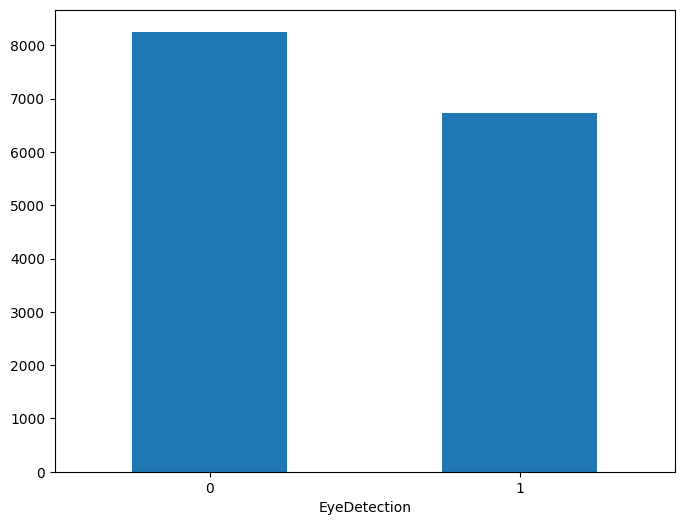

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
count_classes = pd.Series(df['EyeDetection']).value_counts(sort=True)
count_classes.plot(kind = 'bar', rot=0)
plt.show()

In [3]:
# Rename the target variable
df.rename(columns={'EyeDetection': 'target'}, inplace=True)

## Plot the EEG data in time domain

### Plot the EEG data for the first 100 samples


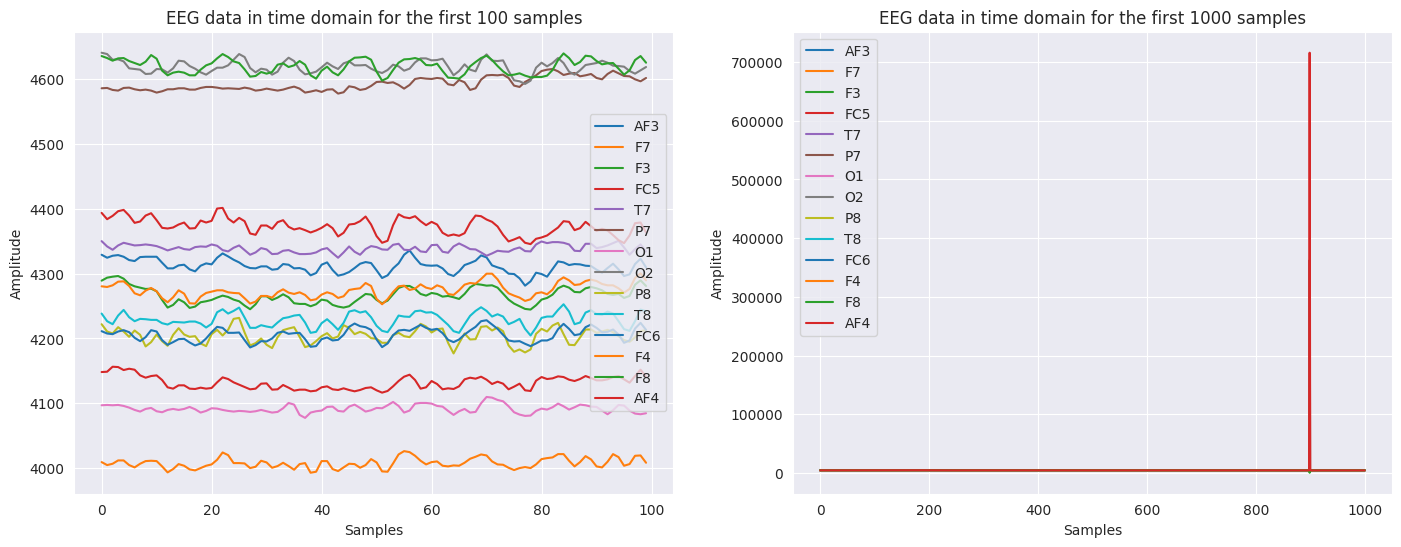

In [5]:
samples = 1000
columns = df.columns[:-1]

fig, axs = plt.subplots(1, 2, figsize=(17, 6))

for i, s in enumerate([100, samples]):
    axs[i].plot(df.iloc[:s, :-1])
    axs[i].legend(df.columns[:-1])
    axs[i].set_xlabel('Samples')
    axs[i].set_ylabel('Amplitude')
    axs[i].set_title(f'EEG data in time domain for the first {s} samples')
plt.show()

### Plot the EEG data in frequency domain

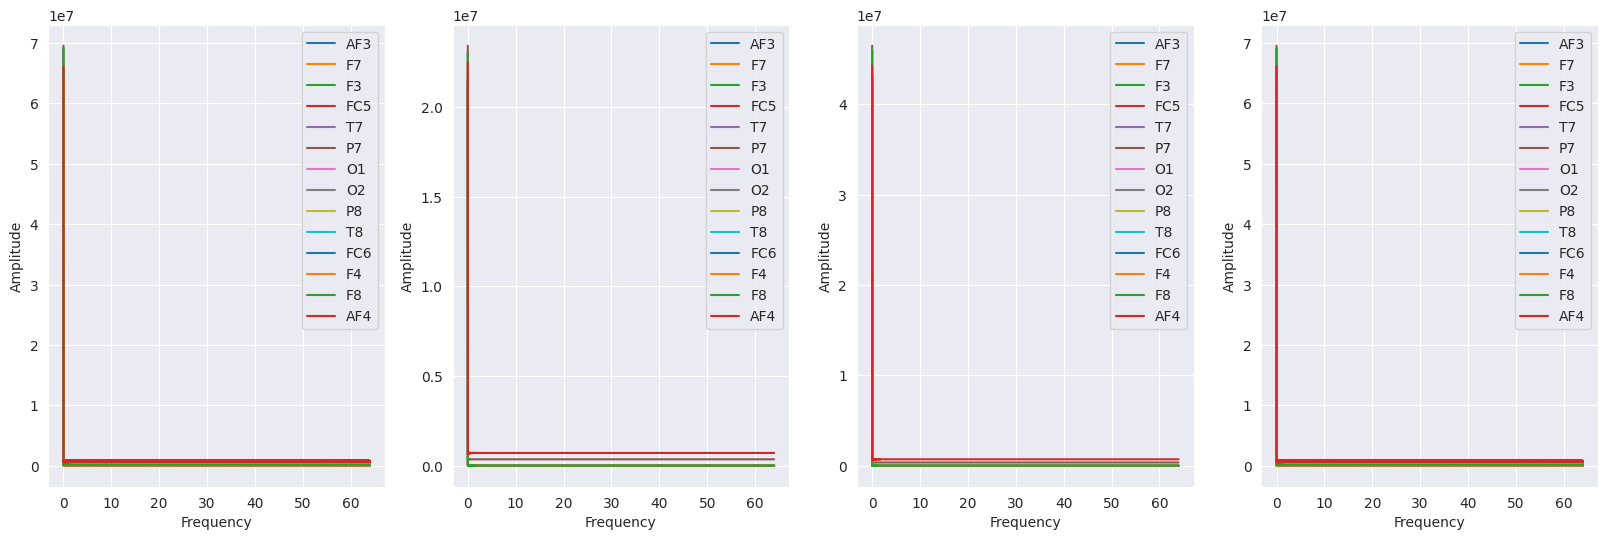

In [50]:
from scipy.fftpack import fft, fftfreq

fs = 128
fig, axs = plt.subplots(1, 4, figsize=(20, 6))

for i, s in enumerate([samples, 5000, 10000, df.shape[0]]):
    signal = np.abs(fft(df.iloc[:s, :-1], axis=0))
    frequencies = fftfreq(s, 1/fs)
    # print(frequencies.shape, signal.shape)
    positive_freqs = frequencies[:len(frequencies)//2]
    for j in range(signal.shape[1]):
        axs[i].plot(positive_freqs, signal[:len(frequencies)//2, j])
    axs[i].legend(df.columns[:-1])
    axs[i].set_xlabel('Frequency')
    axs[i].set_ylabel('Amplitude')
    # axs[i].set_title(f'EEG data in frequency domain for the first {s} samples')
plt.show()


### Plot the EEG data in time-frequency domain

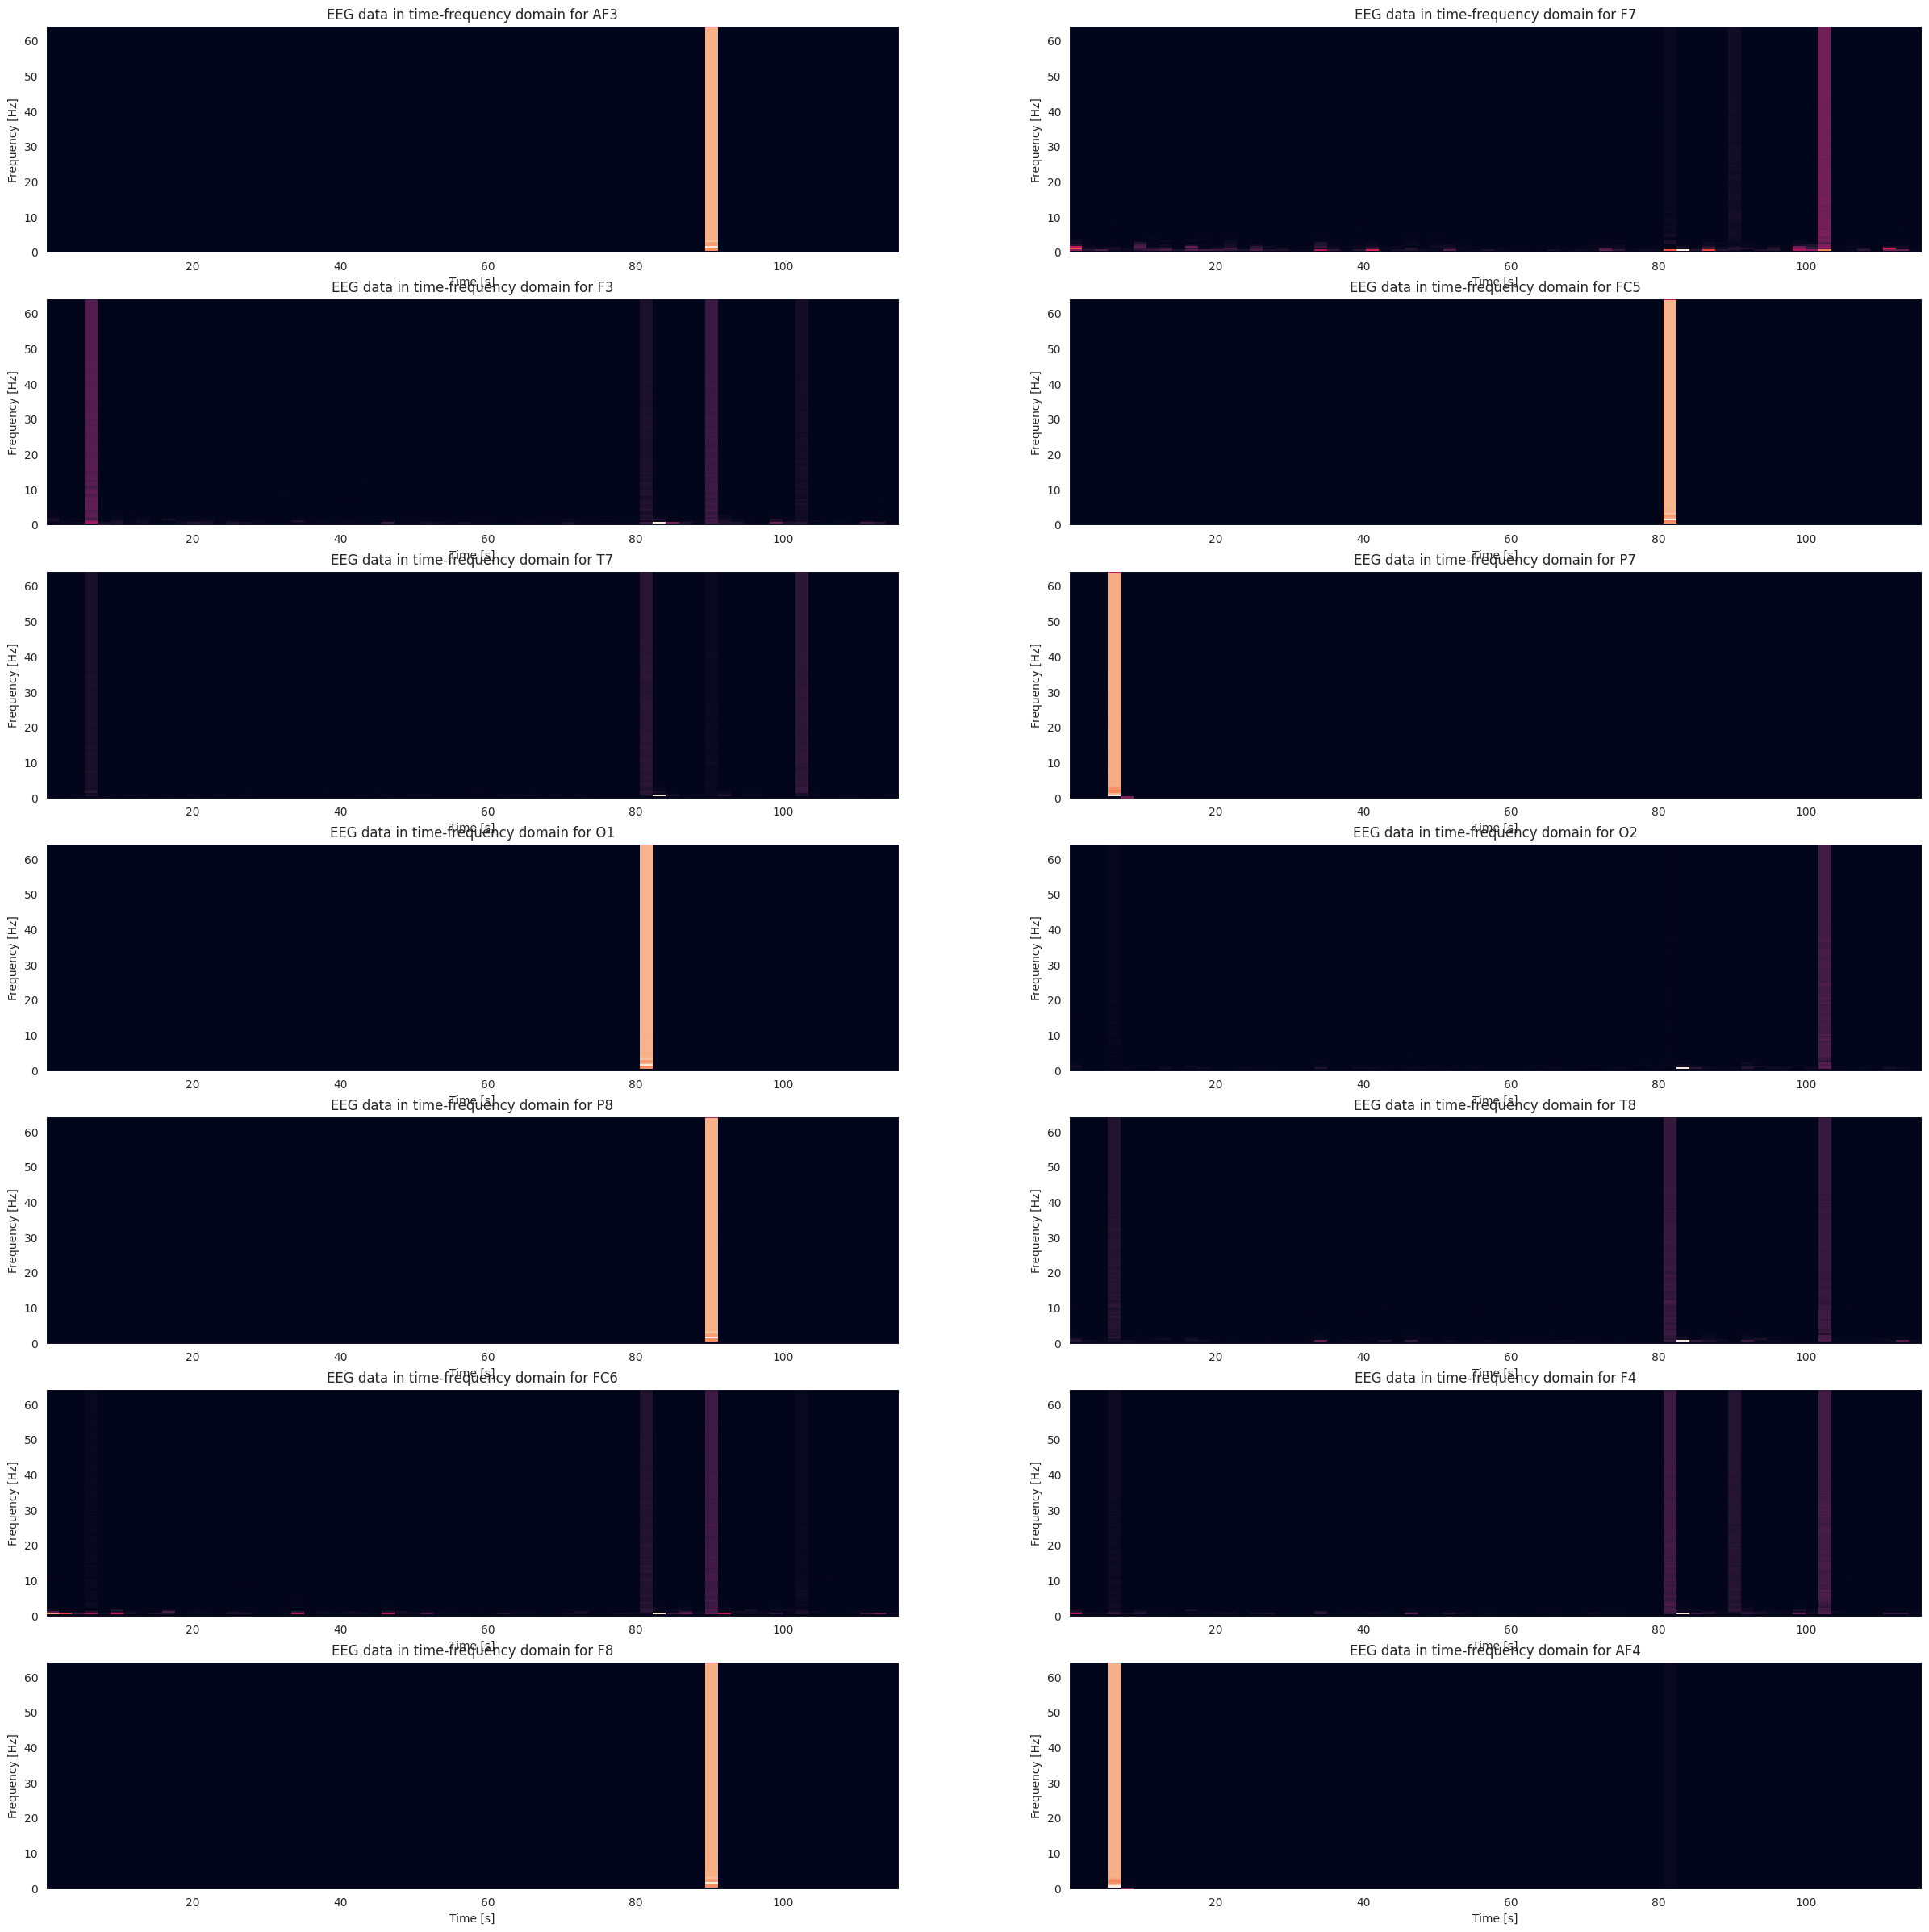

In [45]:
from scipy.signal import spectrogram

columns = df.columns[:-1]
# if we have 15s of data, we can use all the samples, and then assume we have 1000 samples per second
samples = df.shape[0]
fs = 128
nperseg = fs * 2

# Display it in grid
per_row = len(columns) // 2
per_col = 2

fig, axs = plt.subplots(per_row, per_col, figsize=(30, 30))
for column in columns:
    f, t, Sxx = spectrogram(df[column].iloc[:samples], fs=fs, nperseg=nperseg, scaling='spectrum')
    ax = axs[columns.get_loc(column) // per_col, columns.get_loc(column) % per_col]
    ax.pcolormesh(t, f, np.abs(Sxx))
    ax.set_ylabel('Frequency [Hz]')
    ax.set_xlabel('Time [s]') # Todo: what is the unit of time ?
    ax.set_title(f'EEG data in time-frequency domain for {column}')
plt.show()

### Plot the heatmap of the correlation matrix of the features

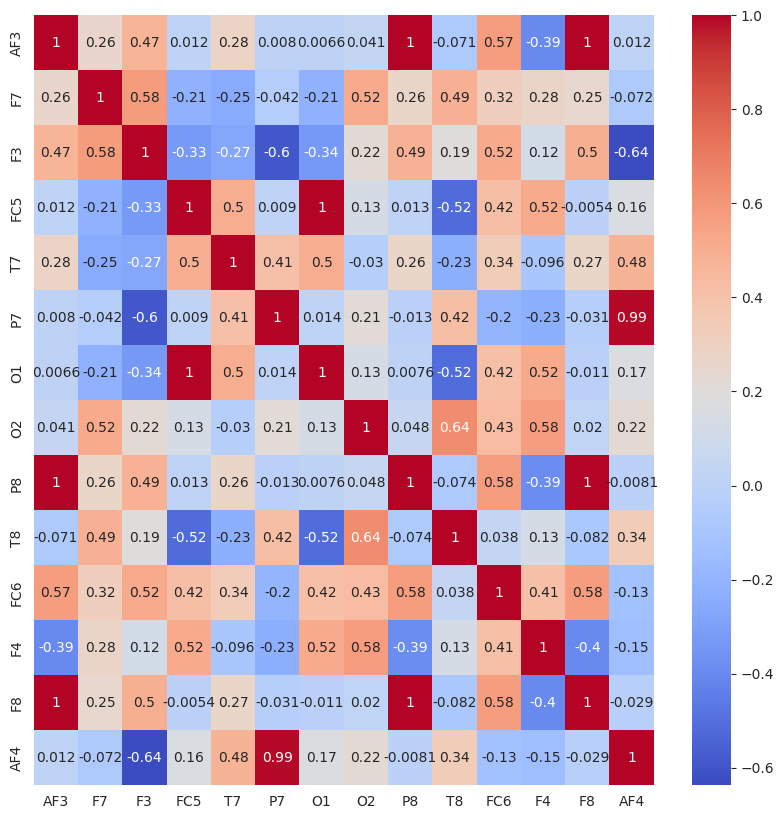

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

corr = df.iloc[:, :-1].corr()
plt.figure(figsize=(10, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


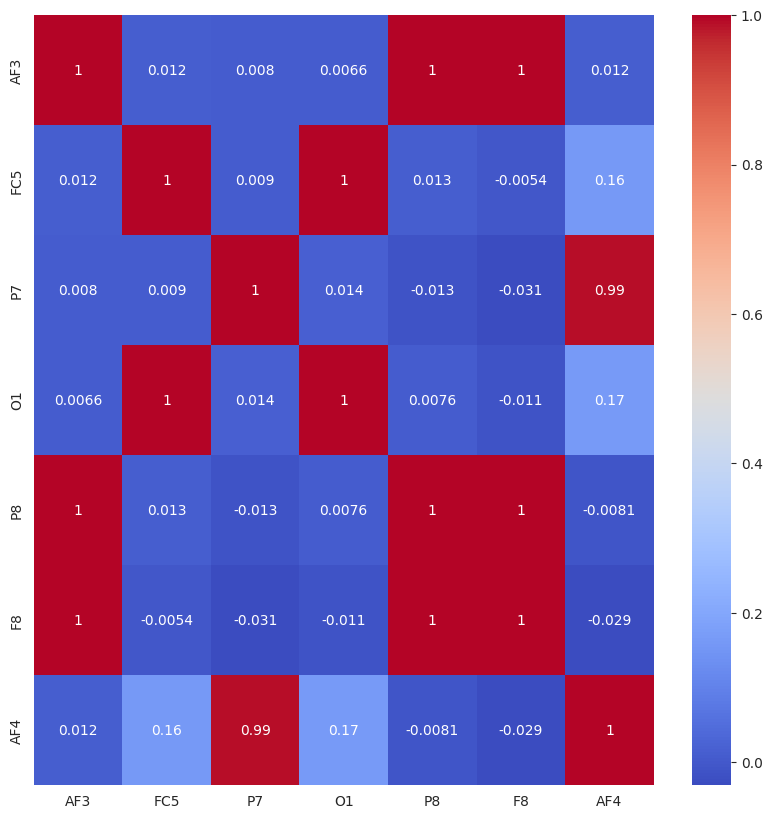

In [27]:
similar_signals = ['AF3', 'FC5', 'P7', 'O1', 'P8', 'F8', 'AF4']
corr = df.loc[:, similar_signals].corr()
plt.figure(figsize=(10, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


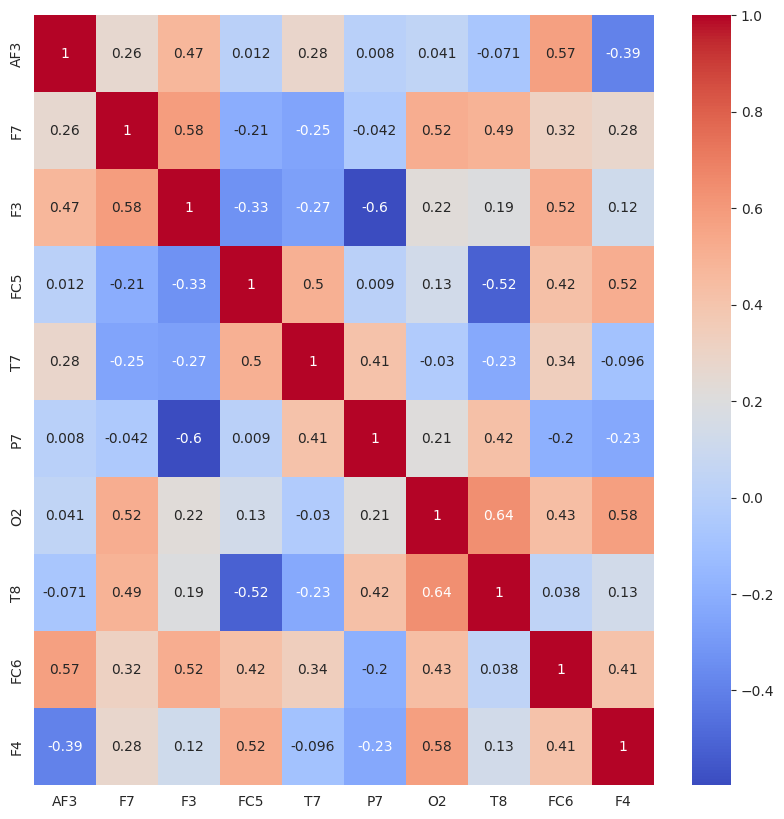

In [31]:
selected_signals = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O2', 'T8', 'FC6', 'F4']

corr = df.loc[:, selected_signals].corr()
plt.figure(figsize=(10, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


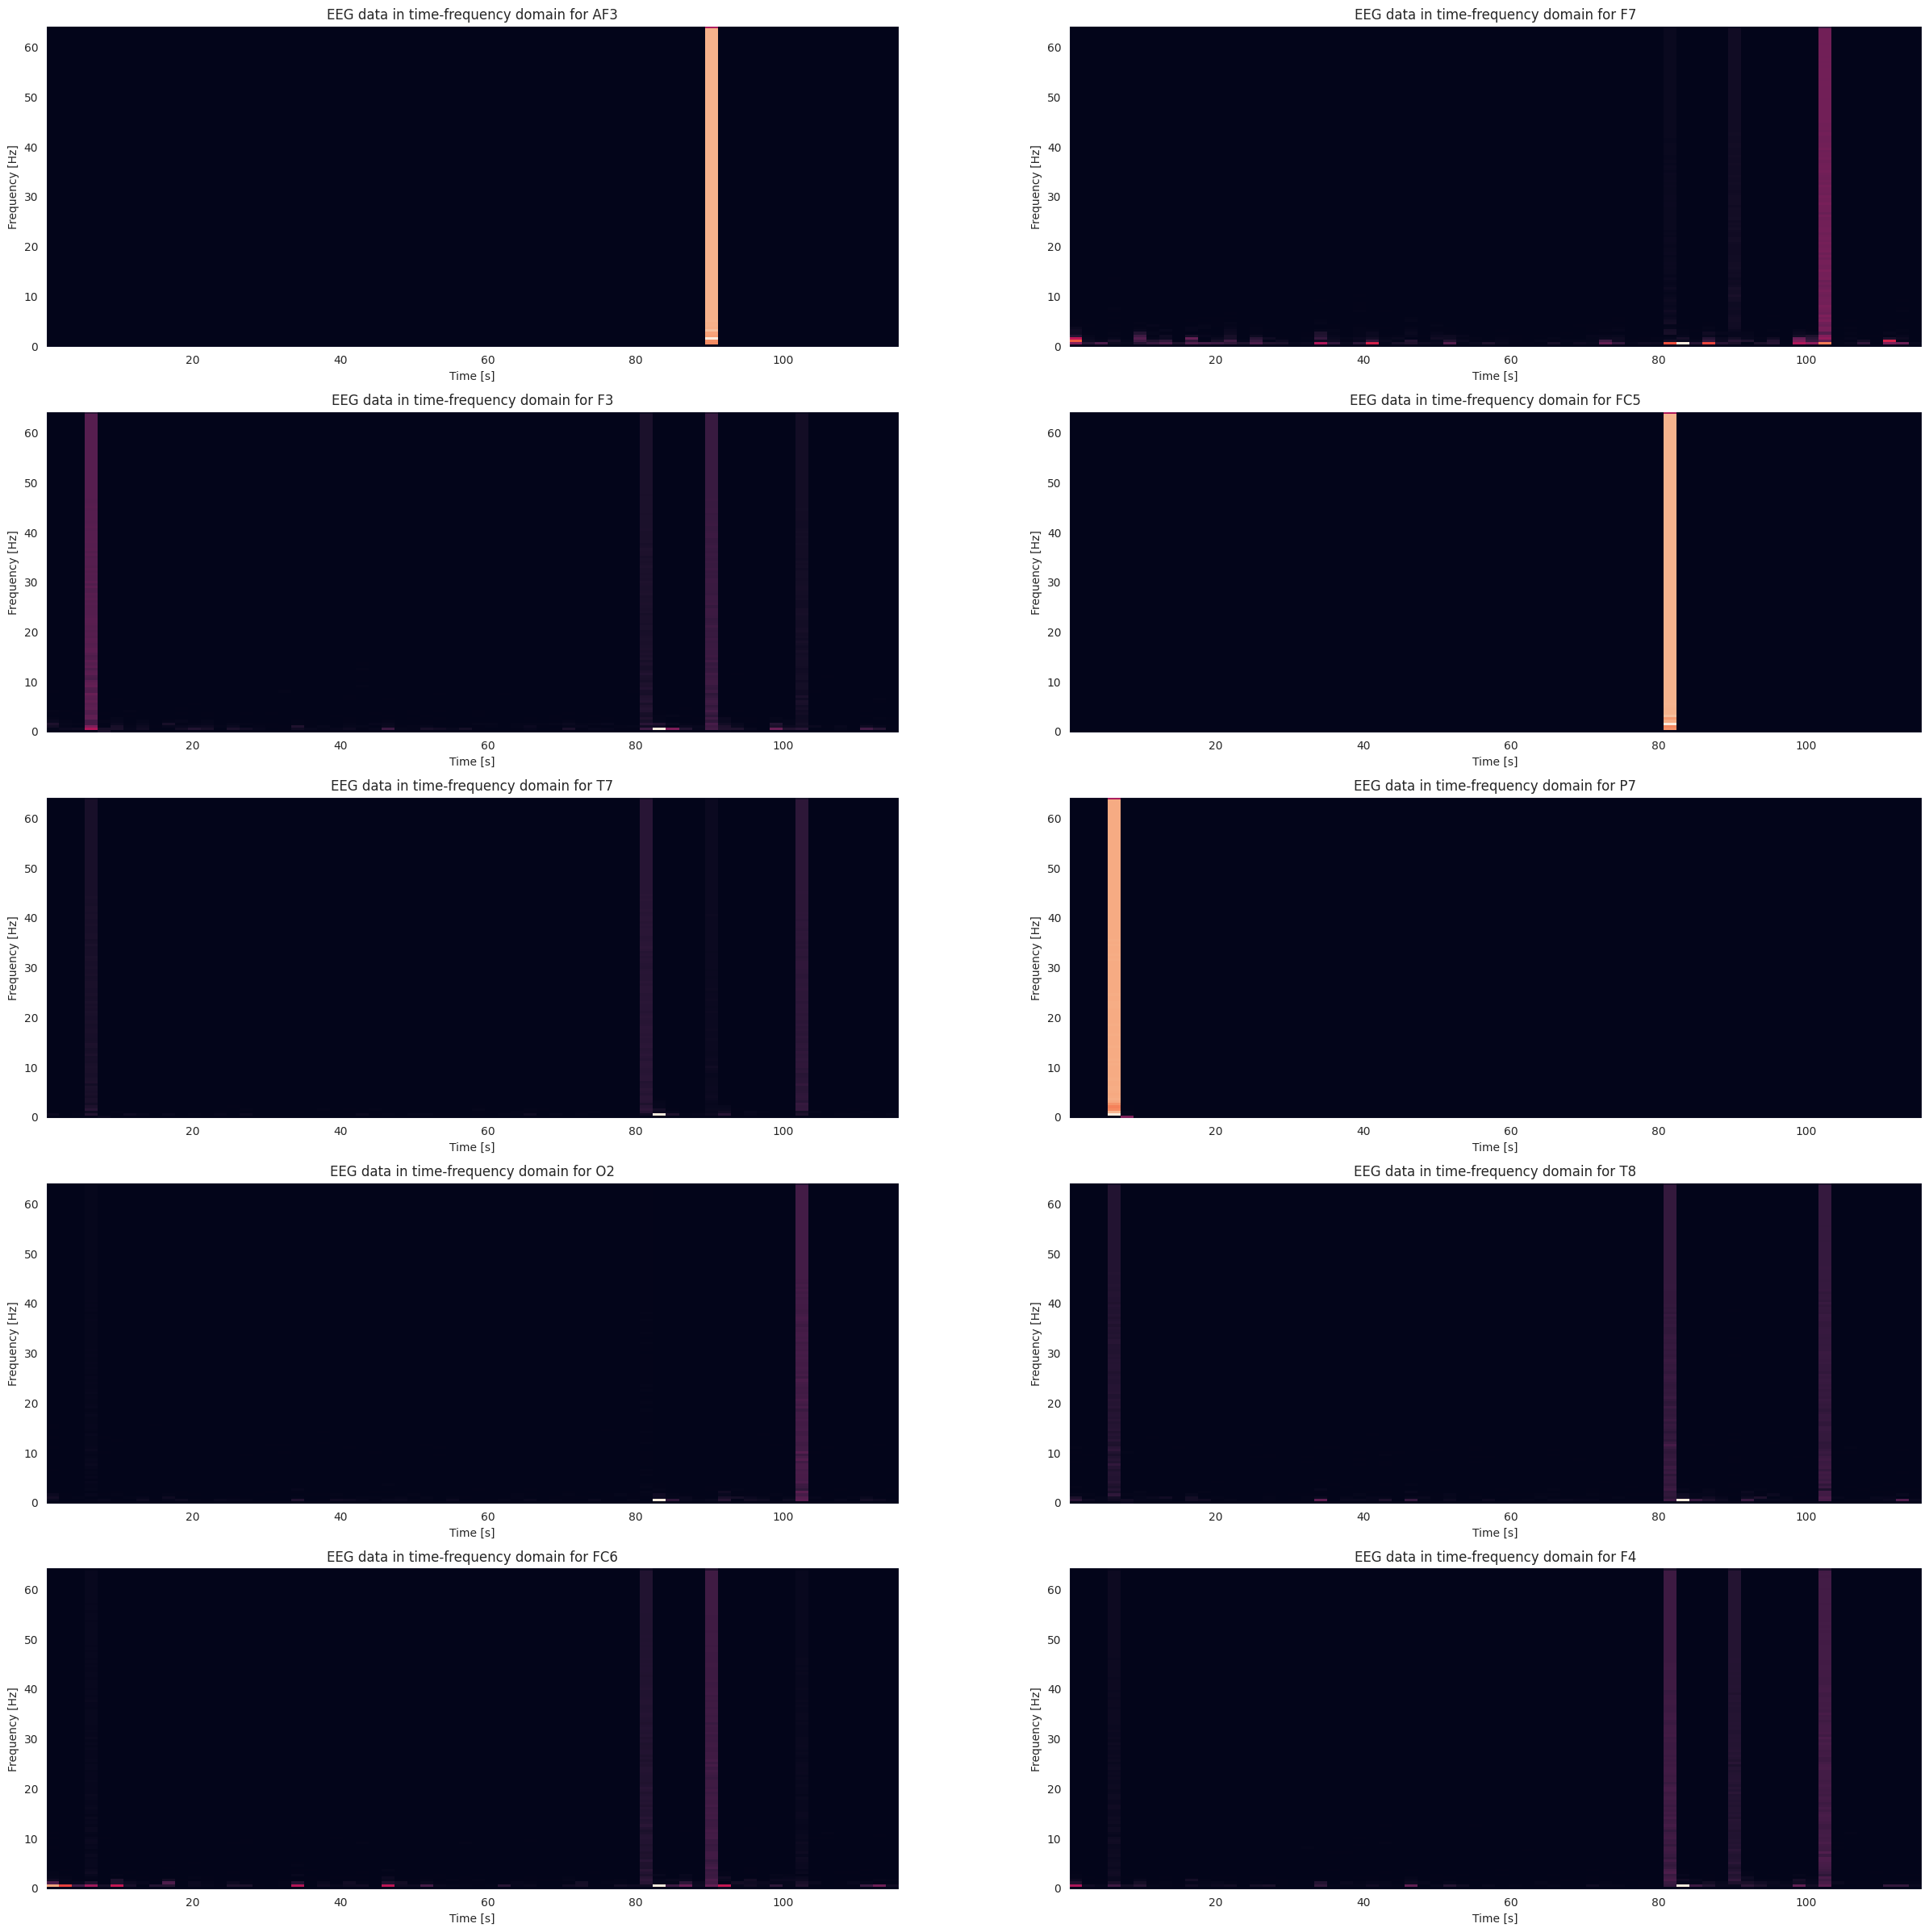

In [36]:
from scipy.signal import spectrogram

columns = df.columns[df.columns.isin(selected_signals)]
# if we have 15s of data, we can use all the samples, and then assume we have 1000 samples per second
samples = df.shape[0]
fs = 128
nperseg = fs * 2

# Display it in grid
per_row = len(columns) // 2
per_col = 2

fig, axs = plt.subplots(per_row, per_col, figsize=(30, 30))
for column in columns:
    f, t, Sxx = spectrogram(df[column].iloc[:samples], fs=fs, nperseg=nperseg, scaling='spectrum')
    ax = axs[columns.get_loc(column) // per_col, columns.get_loc(column) % per_col]
    ax.pcolormesh(t, f, np.abs(Sxx))
    ax.set_ylabel('Frequency [Hz]')
    ax.set_xlabel('Time [s]') # Todo: what is the unit of time ?
    ax.set_title(f'EEG data in time-frequency domain for {column}')
plt.show()

In [40]:
max_time = round(max(t))
print("The record is for approximately", max_time, "seconds")

The record is for approximately 115 seconds


In [44]:
print("Electrodes with high correlation are:",  df.columns[~df.columns.isin(selected_signals)].values[:-1])

Electrodes with high correlation are: ['O1' 'P8' 'F8' 'AF4']


We dropped the columns that have high correlation with each other. We can see that the selected signals are not highly correlated. We then plotted the time-frequency domain of the selected signals. We can see that the signals have different frequency components.

## Plot the power spectral density of the signals

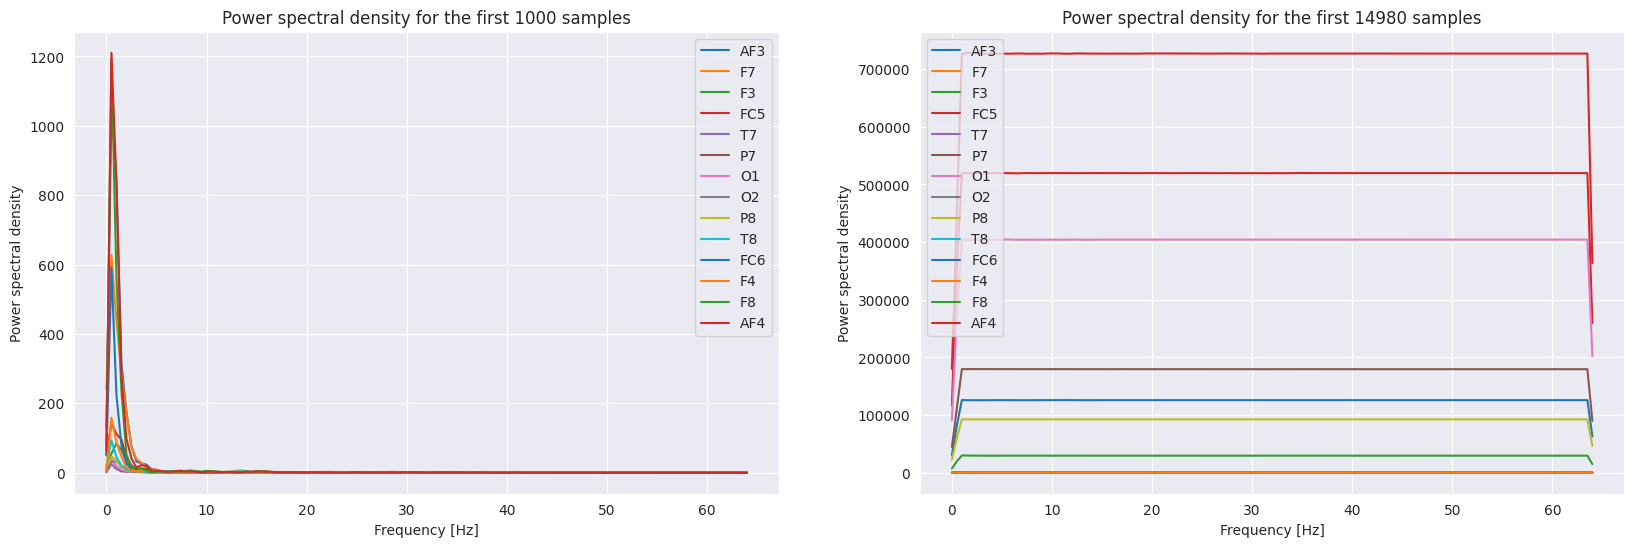

In [53]:
from scipy.signal import welch  


columns = df.columns[:-1]

fig, axs = plt.subplots(1, 2, figsize=(20, 6))

for i, s in enumerate([1000, df.shape[0]]):
    for column in columns:
        f, Pxx = welch(df[column].iloc[:s], fs=fs)
        axs[i].plot(f, Pxx)
    axs[i].legend(df.columns[:-1])
    axs[i].set_xlabel('Frequency [Hz]')
    axs[i].set_ylabel('Power spectral density')
    axs[i].set_title(f'Power spectral density for the first {s} samples')

### Plot the power spectral density 2

We will window the data, apply hamming window and then plot the power spectral density.

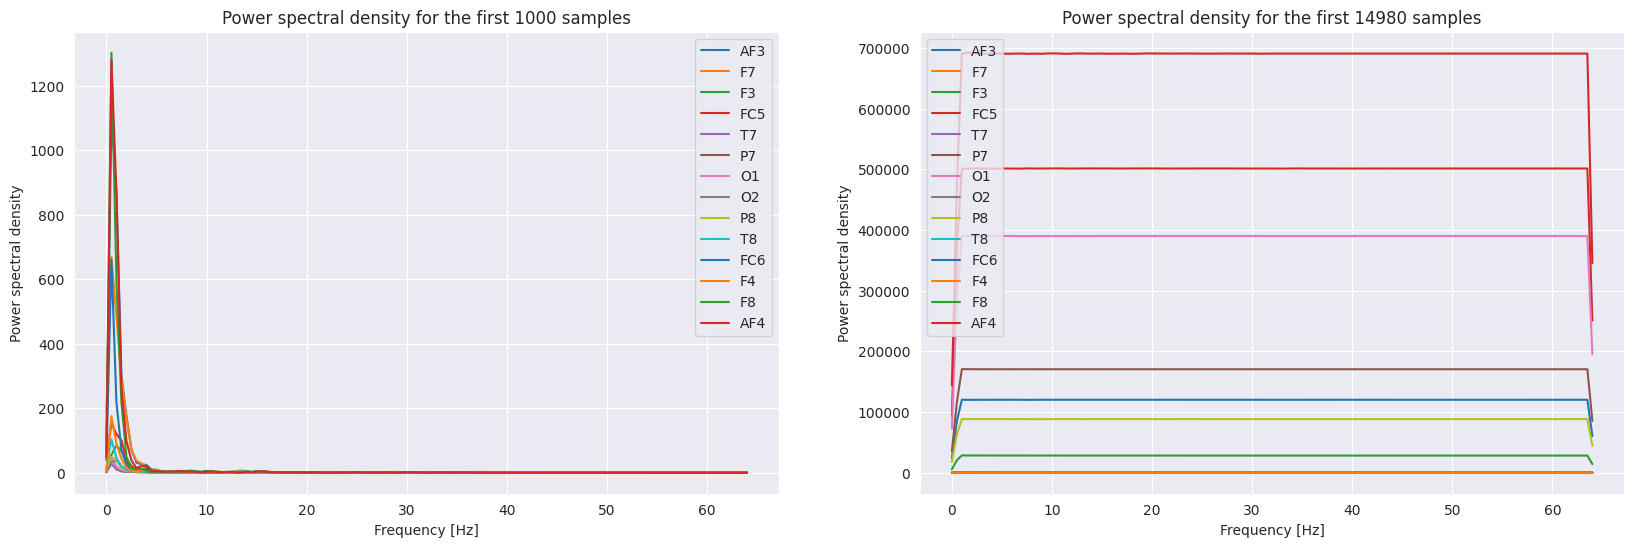

In [54]:
from scipy.signal import welch

columns = df.columns[:-1]

fig, axs = plt.subplots(1, 2, figsize=(20, 6))

for i, s in enumerate([1000, df.shape[0]]):
    for column in columns:
        f, Pxx = welch(df[column].iloc[:s], fs=fs, window='hamming')
        axs[i].plot(f, Pxx)
    axs[i].legend(df.columns[:-1])
    axs[i].set_xlabel('Frequency [Hz]')
    axs[i].set_ylabel('Power spectral density')
    axs[i].set_title(f'Power spectral density for the first {s} samples')

### Plot the spectrogram of the signals 2

We will window the data, apply hamming window and then plot the power spectral density.

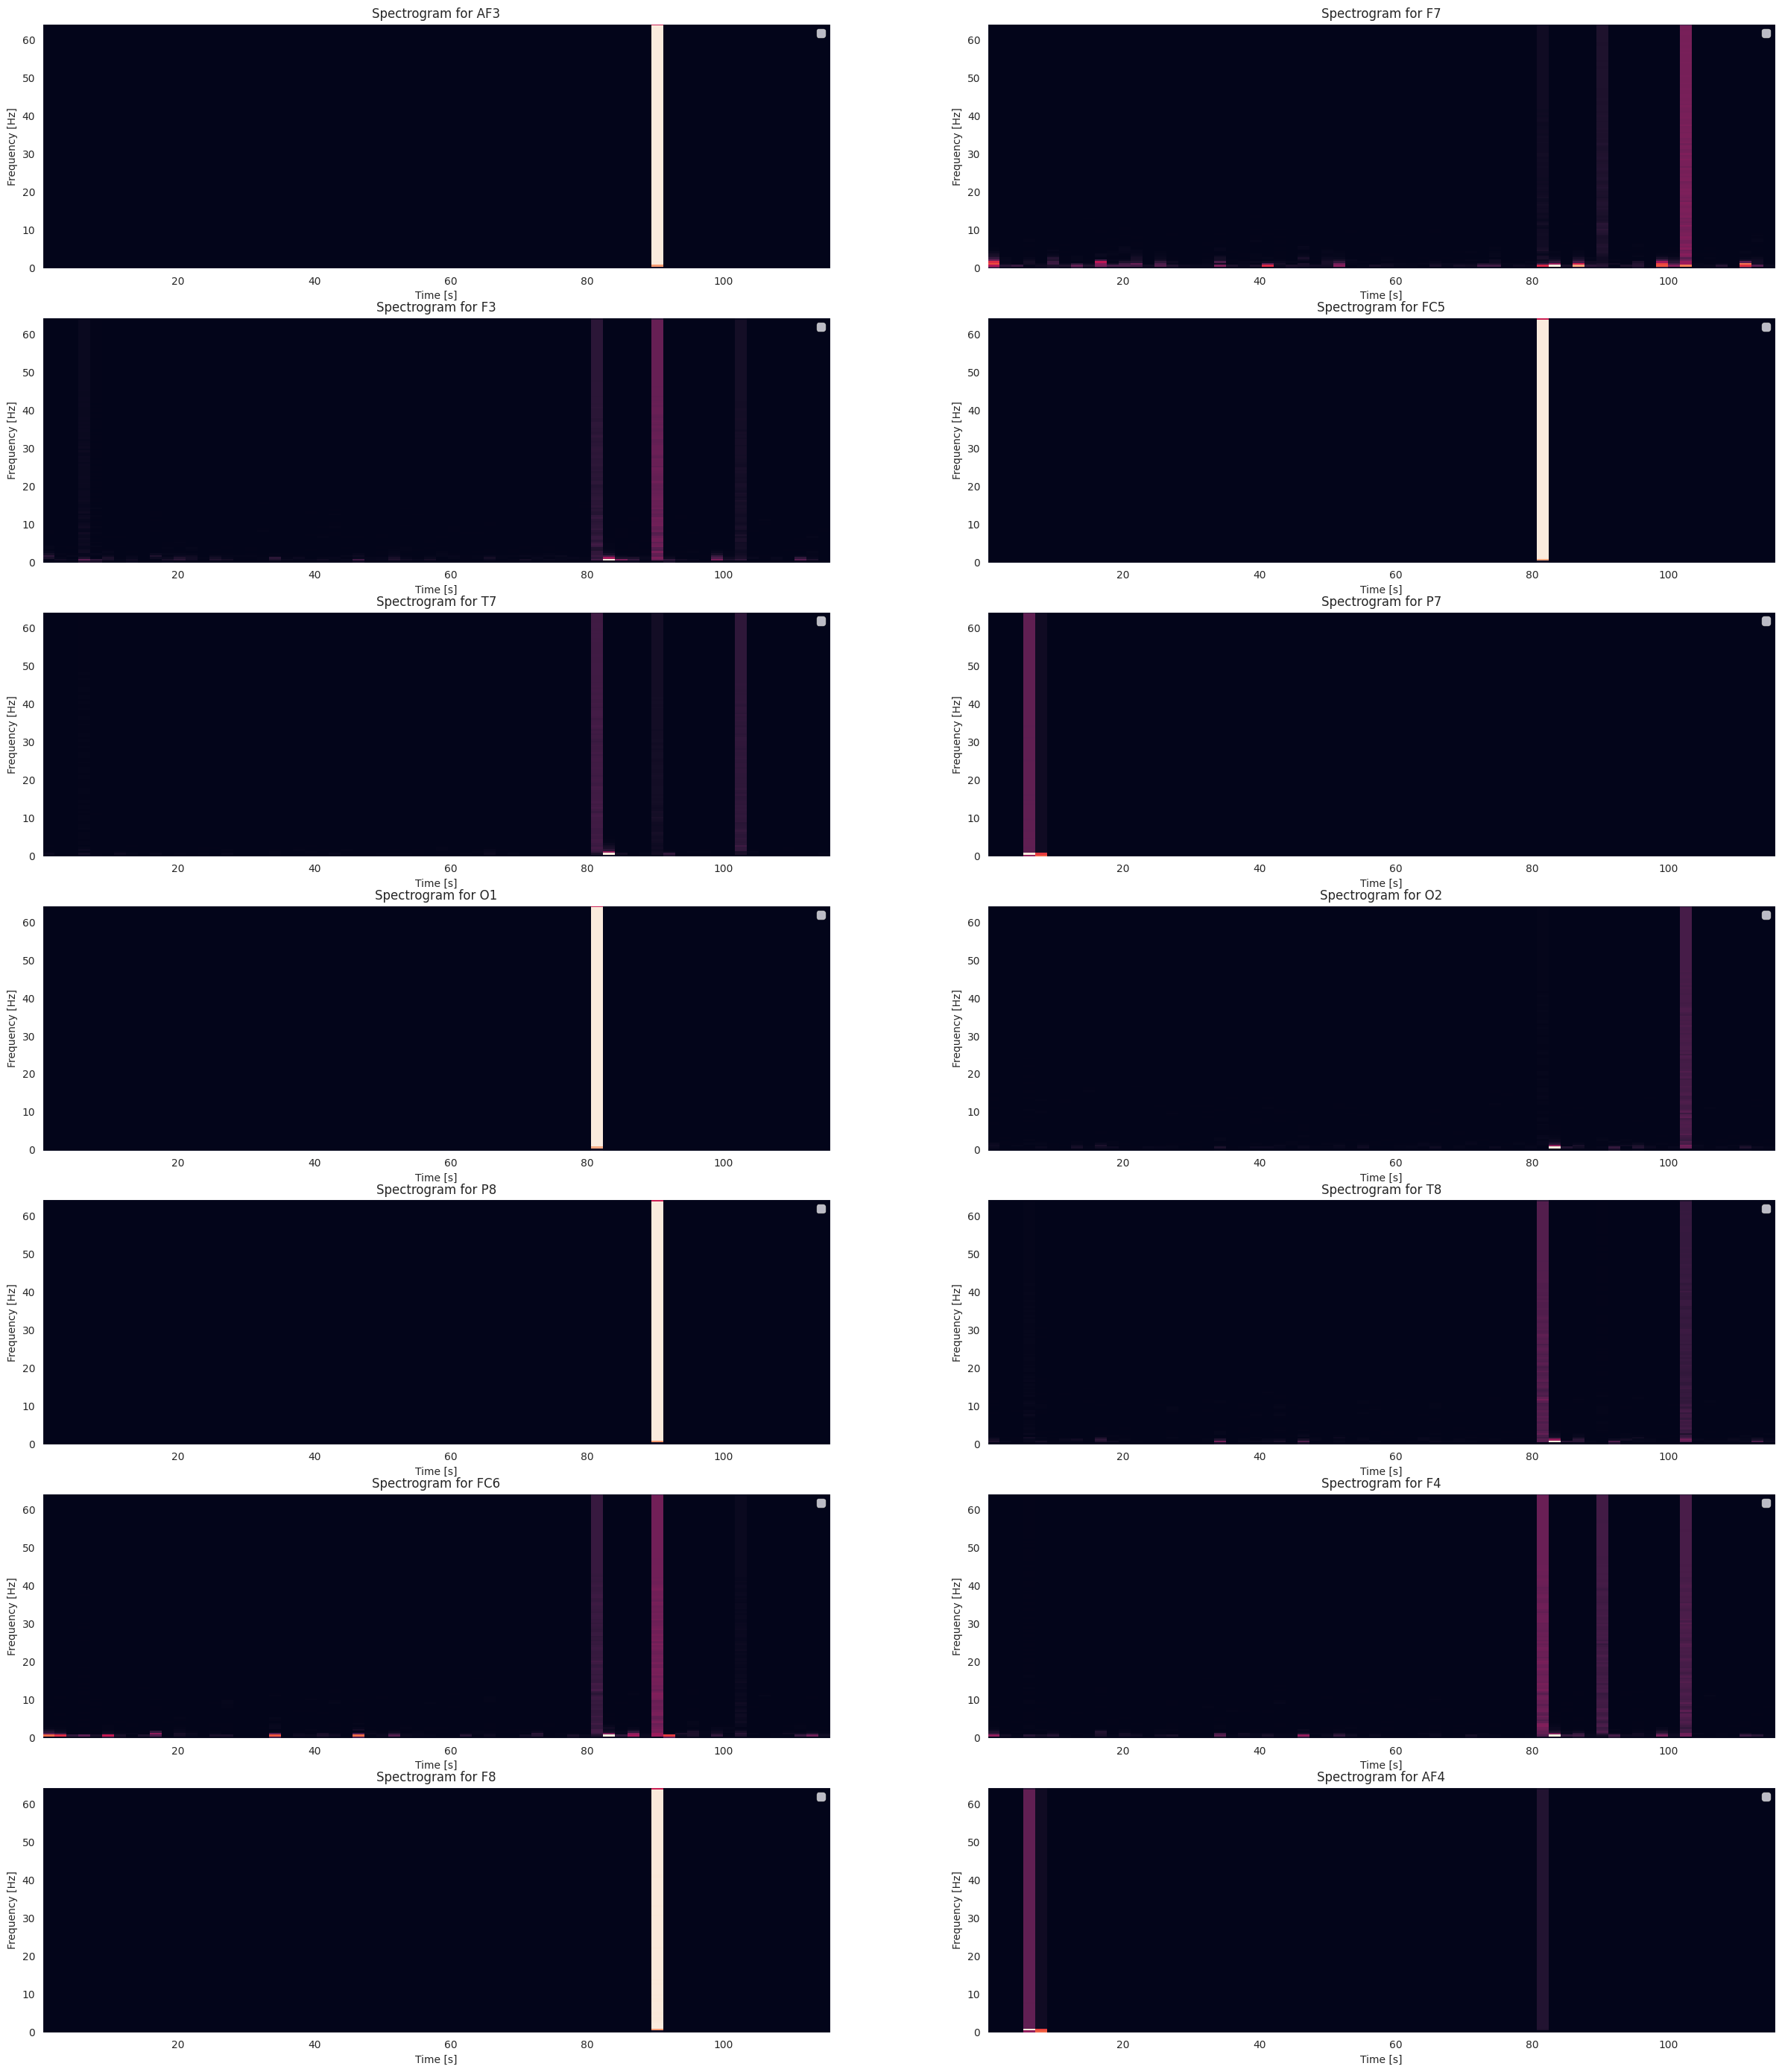

In [59]:
from scipy.signal import spectrogram

columns = df.columns[:-1]

fig, axs = plt.subplots(len(columns)//2, 2, figsize=(30, 35))

for column in columns:
    f, t, Sxx = spectrogram(df[column], fs=fs, nperseg=nperseg, scaling='spectrum', window='hamming')
    ax = axs[columns.get_loc(column) // per_col, columns.get_loc(column) % per_col]
    ax.pcolormesh(t, f, np.abs(Sxx))
    ax.legend(df.columns[:-1])
    ax.set_ylabel('Frequency [Hz]')
    ax.set_xlabel('Time [s]')
    ax.set_title(f'Spectrogram for {column}')

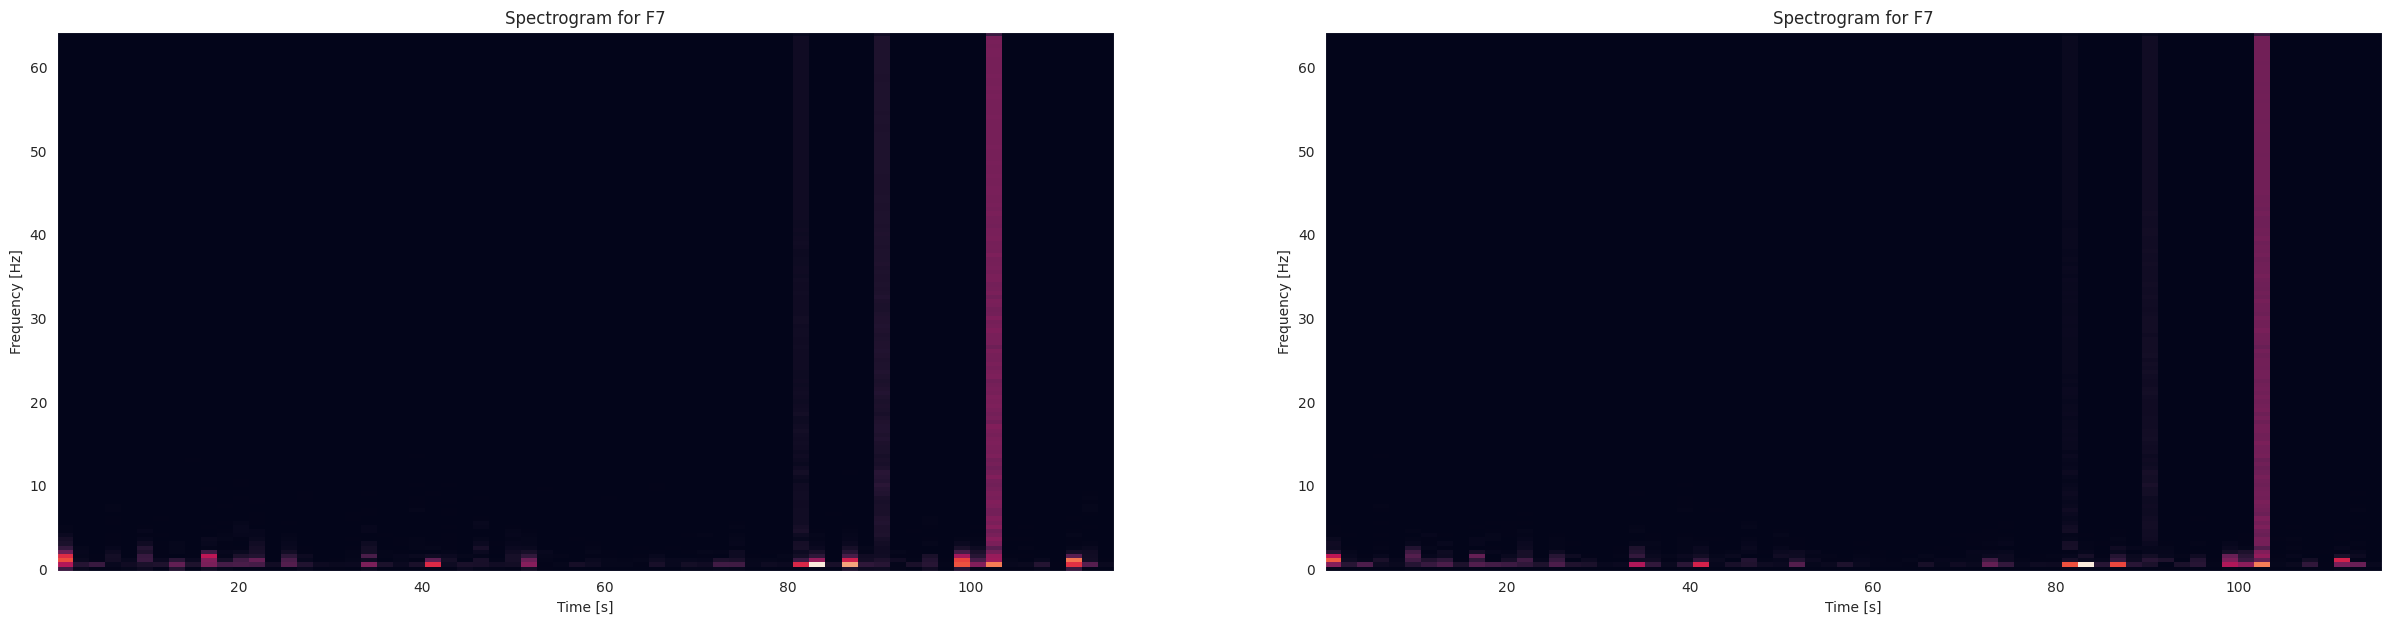

In [61]:
from scipy.signal import spectrogram

column = 'F7'

fig, axs = plt.subplots(1, 2, figsize=(30, 7))

for i in range(2):
    if i == 0:
        f, t, Sxx = spectrogram(df[column], fs=fs, nperseg=nperseg, scaling='spectrum', window='hamming')
    else:
        f, t, Sxx = spectrogram(df[column].iloc[:samples], fs=fs, nperseg=nperseg, scaling='spectrum')
    ax = axs[i]
    ax.pcolormesh(t, f, np.abs(Sxx))
    ax.set_ylabel('Frequency [Hz]')
    ax.set_xlabel('Time [s]')
    ax.set_title(f'Spectrogram for {column}')

## Analyse the power spectral density

In [ ]:
from scipy.signal import welch

columns = df.columns[:-1]

fig, axs = plt.subplots(1, 2, figsize=(20, 6))

for i, s in enumerate([1000, df.shape[0]]):
    for column in columns:
        f, Pxx = welch(df[column].iloc[:s], fs=fs, window='hamming')
        axs[i].plot(f, Pxx)
    axs[i].legend(df.columns[:-1])
    axs[i].set_xlabel('Frequency [Hz]')
    axs[i].set_ylabel('Power spectral density')
    axs[i].set_title(f'Power spectral density for the first {s} samples')

Le graphique ci-dessus représente la densité spectrale de puissance (PSD) de plusieurs canaux EEG sur une plage de fréquences allant de 0 à 60 Hz. Voici quelques points d'analyse qu'on peut en tirer :

1. **Activité dominante à basse fréquence** : Il semble y avoir une concentration de puissance significative autour des très basses fréquences (proche de 0 Hz), ce qui peut correspondre à des artefacts de mouvement ou une activité cérébrale très lente. En général, une puissance élevée à ces fréquences peut également être due à des bruits de basse fréquence (comme les mouvements oculaires ou de tête).

2. **Bande alpha (8-12 Hz)** : Cette bande est importante pour évaluer l'activité dans des états de repos calme, en particulier dans les électrodes occipitales (O1, O2). Cependant, sur ce graphique, il n'y a pas de pic très évident dans cette bande, ce qui peut indiquer une absence ou une faiblesse de l'activité alpha, ou bien que l'échantillon analysé ne représente pas un état de repos typique.

3. **Bande beta (12-30 Hz)** : L’activité dans cette bande est généralement associée à une activité mentale active, des tâches cognitives ou des mouvements moteurs. Ici, il semble que la puissance reste relativement stable dans cette gamme, sans pic notable.

4. **Haute fréquence (>30 Hz)** : Il y a une élévation continue de la puissance au-delà de 30 Hz, ce qui pourrait indiquer la présence de bruit ou d'artefacts, comme des interférences provenant d’équipements externes ou des mouvements musculaires.

5. **Fréquence de 50-60 Hz** : Cette région est généralement associée aux bruits de réseau électrique (en fonction du pays, il peut s'agir de 50 Hz ou de 60 Hz). L'augmentation visible ici vers la fin pourrait indiquer la présence de ce type de bruit dans les signaux.

En résumé, ce PSD semble indiquer que le signal EEG contient des éléments à très basse fréquence (possiblement des artefacts) et des bruits potentiels dans les hautes fréquences. Il serait intéressant de filtrer ces artefacts et bruits pour mieux analyser les bandes de fréquences pertinentes (comme alpha, beta, theta).

Si cet EEG a été enregistré pendant 2 minutes, en observant le sujet avec les yeux ouverts et fermés, plusieurs éléments peuvent être pris en compte pour l'analyse du signal en fonction des périodes d'ouverture et de fermeture des yeux :

1. **Bande Alpha (8-12 Hz)** :
   - **Yeux fermés** : Normalement, lorsqu'une personne est dans un état de repos calme avec les yeux fermés, une augmentation de l'activité alpha est attendue, principalement dans les régions occipitales (O1, O2). Cependant, dans ton graphique, il ne semble pas y avoir de pic marqué dans la bande alpha.
   - **Yeux ouverts** : Lorsqu'une personne ouvre les yeux, l'activité alpha a tendance à diminuer (désynchronisation alpha). On peut s'attendre à ce que la puissance dans cette bande diminue lorsque le sujet ouvre les yeux.

2. **Absence de Pic Alpha** :
   - Dans le graphique, on ne voit pas de pic évident dans la bande alpha entre 8 et 12 Hz, ce qui pourrait indiquer plusieurs choses :
     - **Absence de production d'ondes alpha** : Cela pourrait être lié à l'état d'alerte du sujet ou à des conditions où l'activité alpha est inhibée.
     - **Bruit dans le signal** : Le bruit présent à basse fréquence ou dans les bandes supérieures pourrait masquer l'activité alpha, ce qui rend plus difficile la distinction de cette bande spécifique.
     - **Problèmes techniques** : Il pourrait y avoir des interférences dans les canaux EEG qui affectent la qualité du signal, surtout dans les électrodes occipitales.

3. **Présence d'artefacts** :
   - **Basses fréquences** : L'augmentation importante dans les très basses fréquences pourrait être due à des artefacts de mouvement, comme les mouvements oculaires, qui sont fréquents dans des expériences où les sujets ouvrent et ferment les yeux.
   - **Bruitage électrique** : La hausse dans la bande 50-60 Hz peut être du bruit provenant du réseau électrique, ce qui peut interférer avec l'analyse des fréquences d'intérêt.

### Analyse comparative :
- **Yeux ouverts** : Si l'on compare les périodes où les yeux sont ouverts, on s'attend à voir moins d'activité dans la bande alpha et peut-être une augmentation dans les bandes beta (12-30 Hz), associée à l'activité cognitive et visuelle.
- **Yeux fermés** : Durant les périodes où les yeux sont fermés, un pic d'ondes alpha dans les régions occipitales est normalement visible.

### Conclusion :
L'absence d'un pic alpha marqué dans le PSD pourrait indiquer que l'activité alpha n'est pas bien détectée dans ce signal, soit à cause d'un bruit important ou de la condition du sujet pendant l'enregistrement (par exemple, s'il ne se trouve pas dans un état de repos calme). Il serait intéressant d'isoler les périodes de fermeture et d'ouverture des yeux pour comparer leurs PSD respectifs. Cela permettrait de confirmer si des changements significatifs dans l'activité alpha se produisent, comme attendu.

### ICA and noise removal

#### ICA

We will detect the independent components of the signals using ICA. To choose the right number of components, we will use PCA and use the number of components that explain 95% of the variance. We will do so for each signal and plot the independent components.

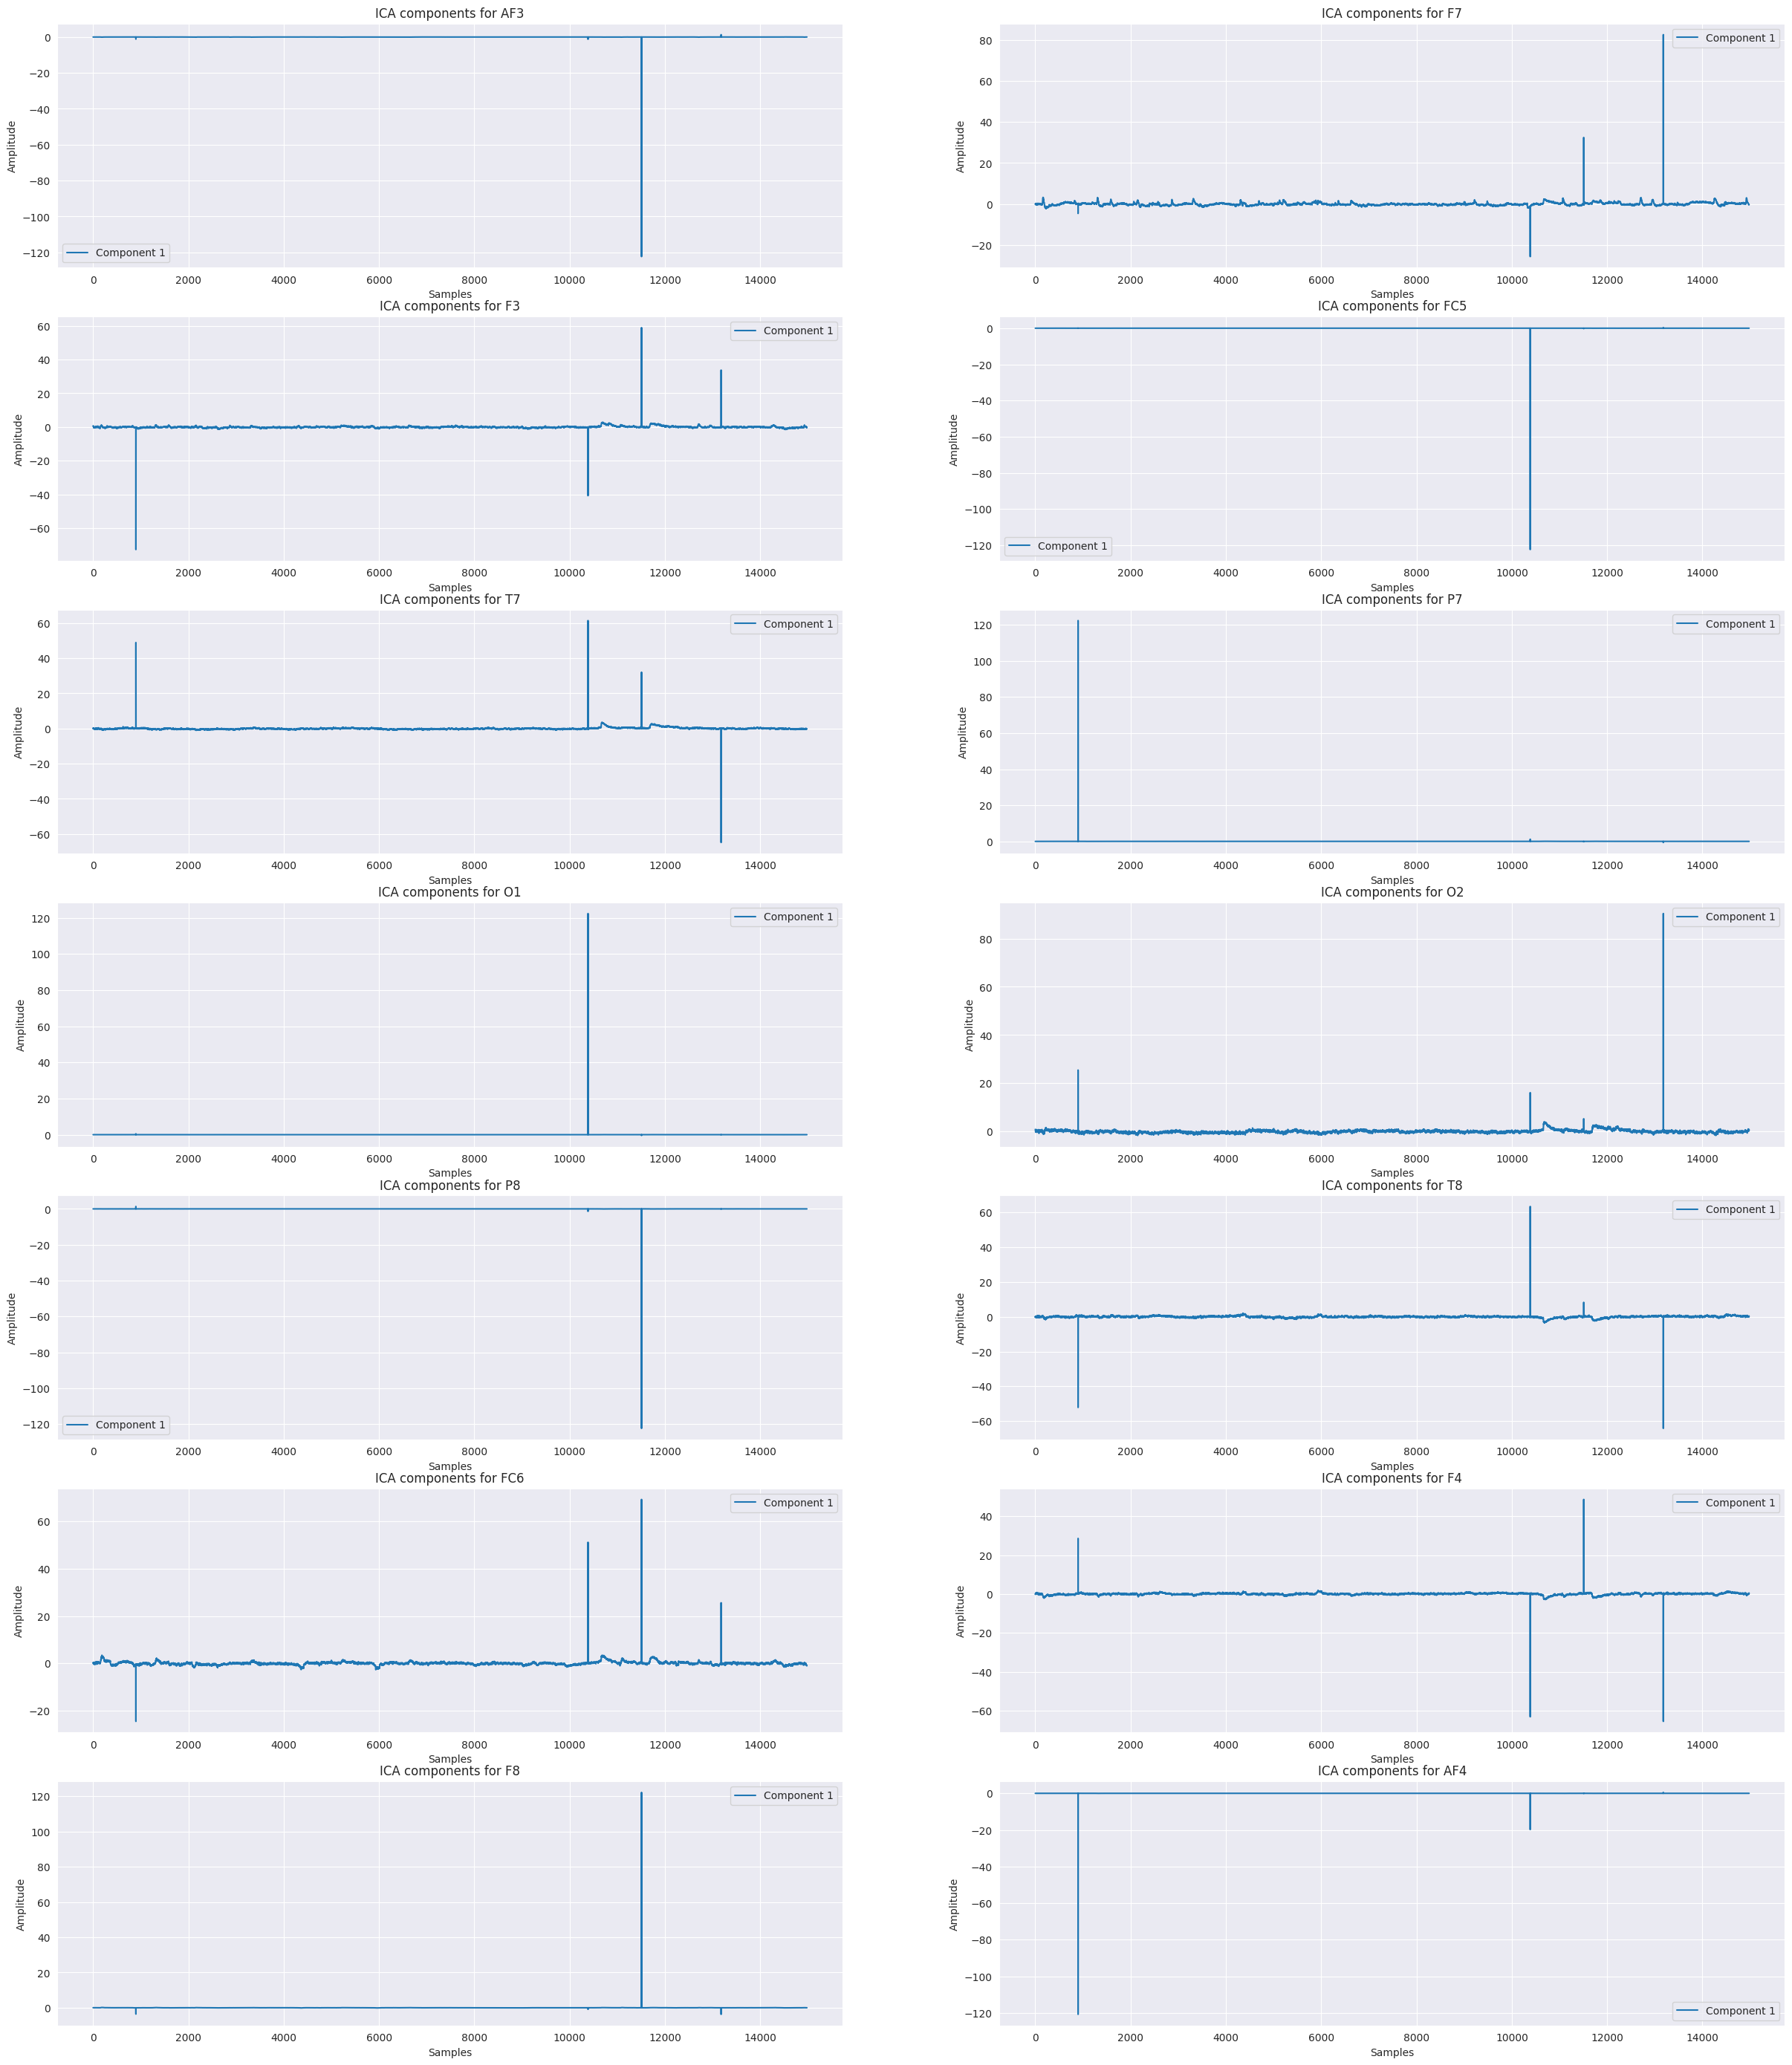

In [64]:
from sklearn.decomposition import FastICA, PCA

columns = df.columns[:-1]

fig, axs = plt.subplots(len(columns)//2, 2, figsize=(30, 35))

for column in columns:
    pca = PCA(n_components=0.95)
    pca.fit(df[column].values.reshape(-1, 1))
    n_components = pca.n_components_
    ica = FastICA(n_components=n_components)
    components = ica.fit_transform(df[column].values.reshape(-1, 1))
    ax = axs[columns.get_loc(column) // per_col, columns.get_loc(column) % per_col]
    ax.plot(components)
    ax.legend([f'Component {i+1}' for i in range(n_components)])
    ax.set_xlabel('Samples')
    ax.set_ylabel('Amplitude')
    ax.set_title(f'ICA components for {column}')

(14980, 1) (14980,)
(14980, 1) (14980,)
(14980, 1) (14980,)
(14980, 1) (14980,)
(14980, 1) (14980,)
(14980, 1) (14980,)
(14980, 1) (14980,)
(14980, 1) (14980,)
(14980, 1) (14980,)
(14980, 1) (14980,)
(14980, 1) (14980,)
(14980, 1) (14980,)
(14980, 1) (14980,)
(14980, 1) (14980,)


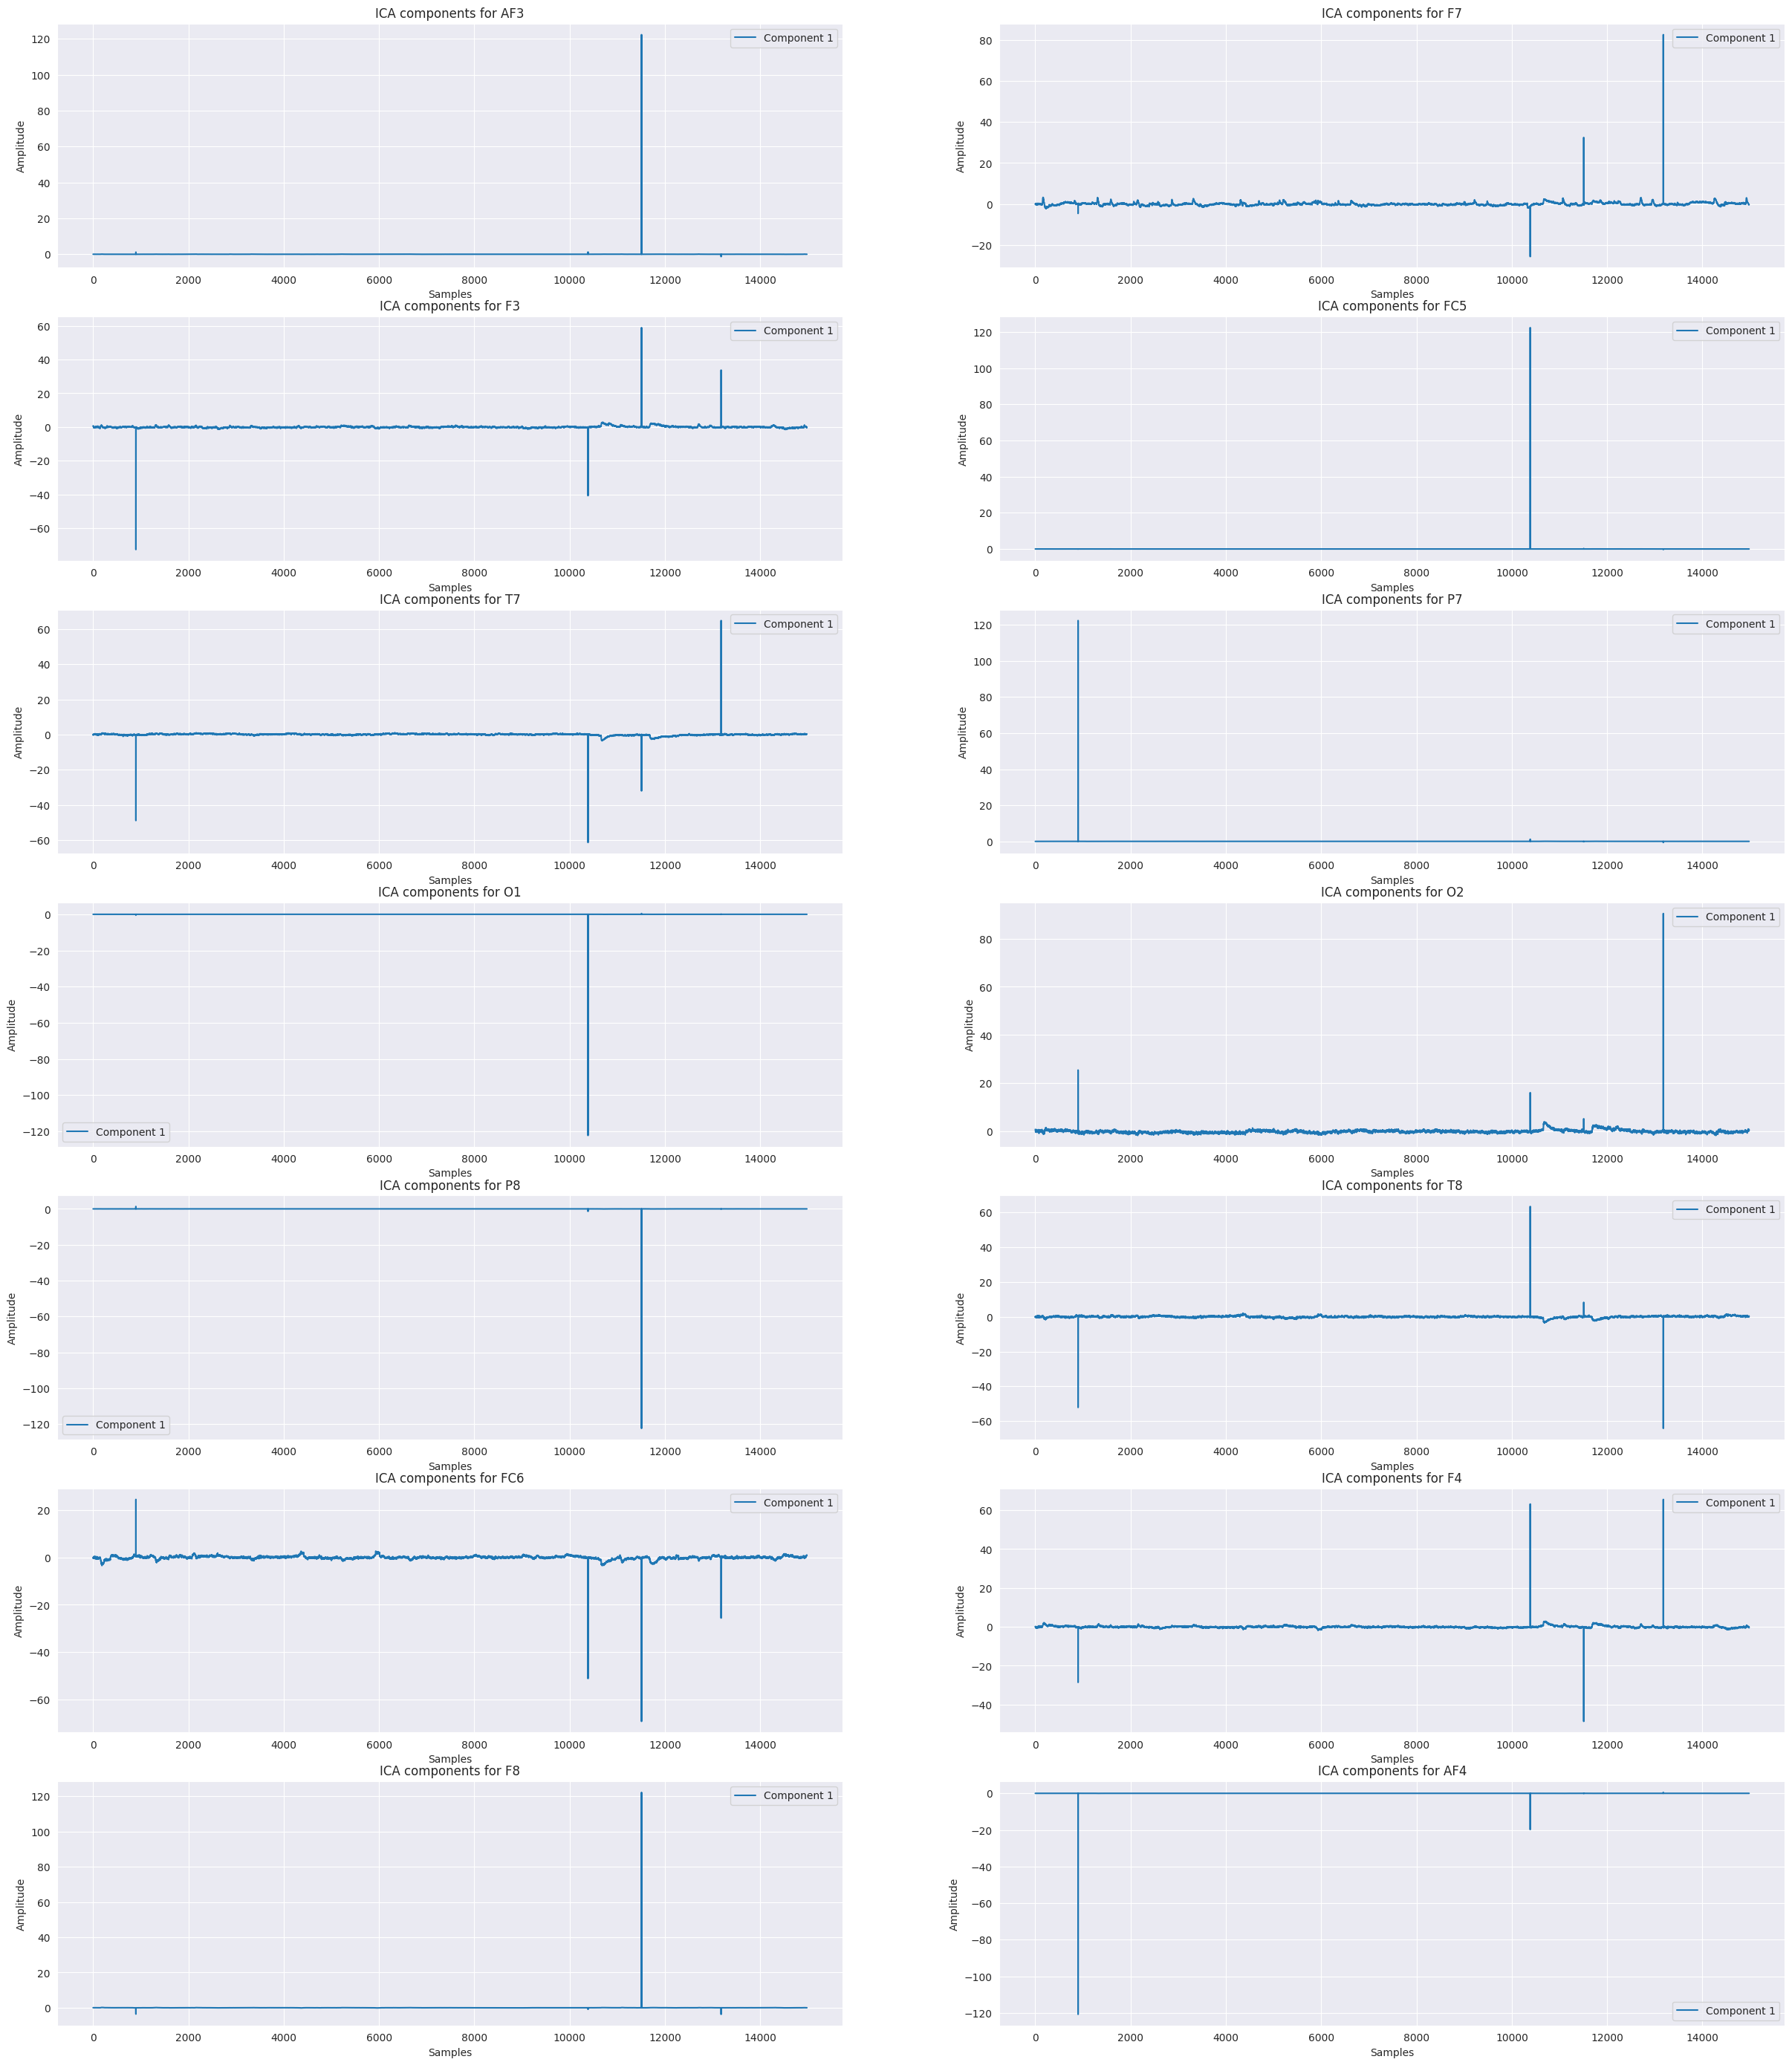

In [66]:
from sklearn.decomposition import FastICA, PCA

columns = df.columns[:-1]

fig, axs = plt.subplots(len(columns)//2, 2, figsize=(30, 35))

for column in columns:
    pca = PCA(n_components=0.95)
    pca.fit(df[column].values.reshape(-1, 1))
    n_components = pca.n_components_
    ica = FastICA(n_components=n_components)
    components = ica.fit_transform(df[column].values.reshape(-1, 1))
    ax = axs[columns.get_loc(column) // per_col, columns.get_loc(column) % per_col]
    ax.plot(components)
    ax.legend([f'Component {i+1}' for i in range(n_components)])
    ax.set_xlabel('Samples')
    ax.set_ylabel('Amplitude')
    ax.set_title(f'ICA components for {column}')

### Plot bandpower of each signal

We will calculate the bandpower of each signal and plot it. We will plot the relative bandpower of each signal.

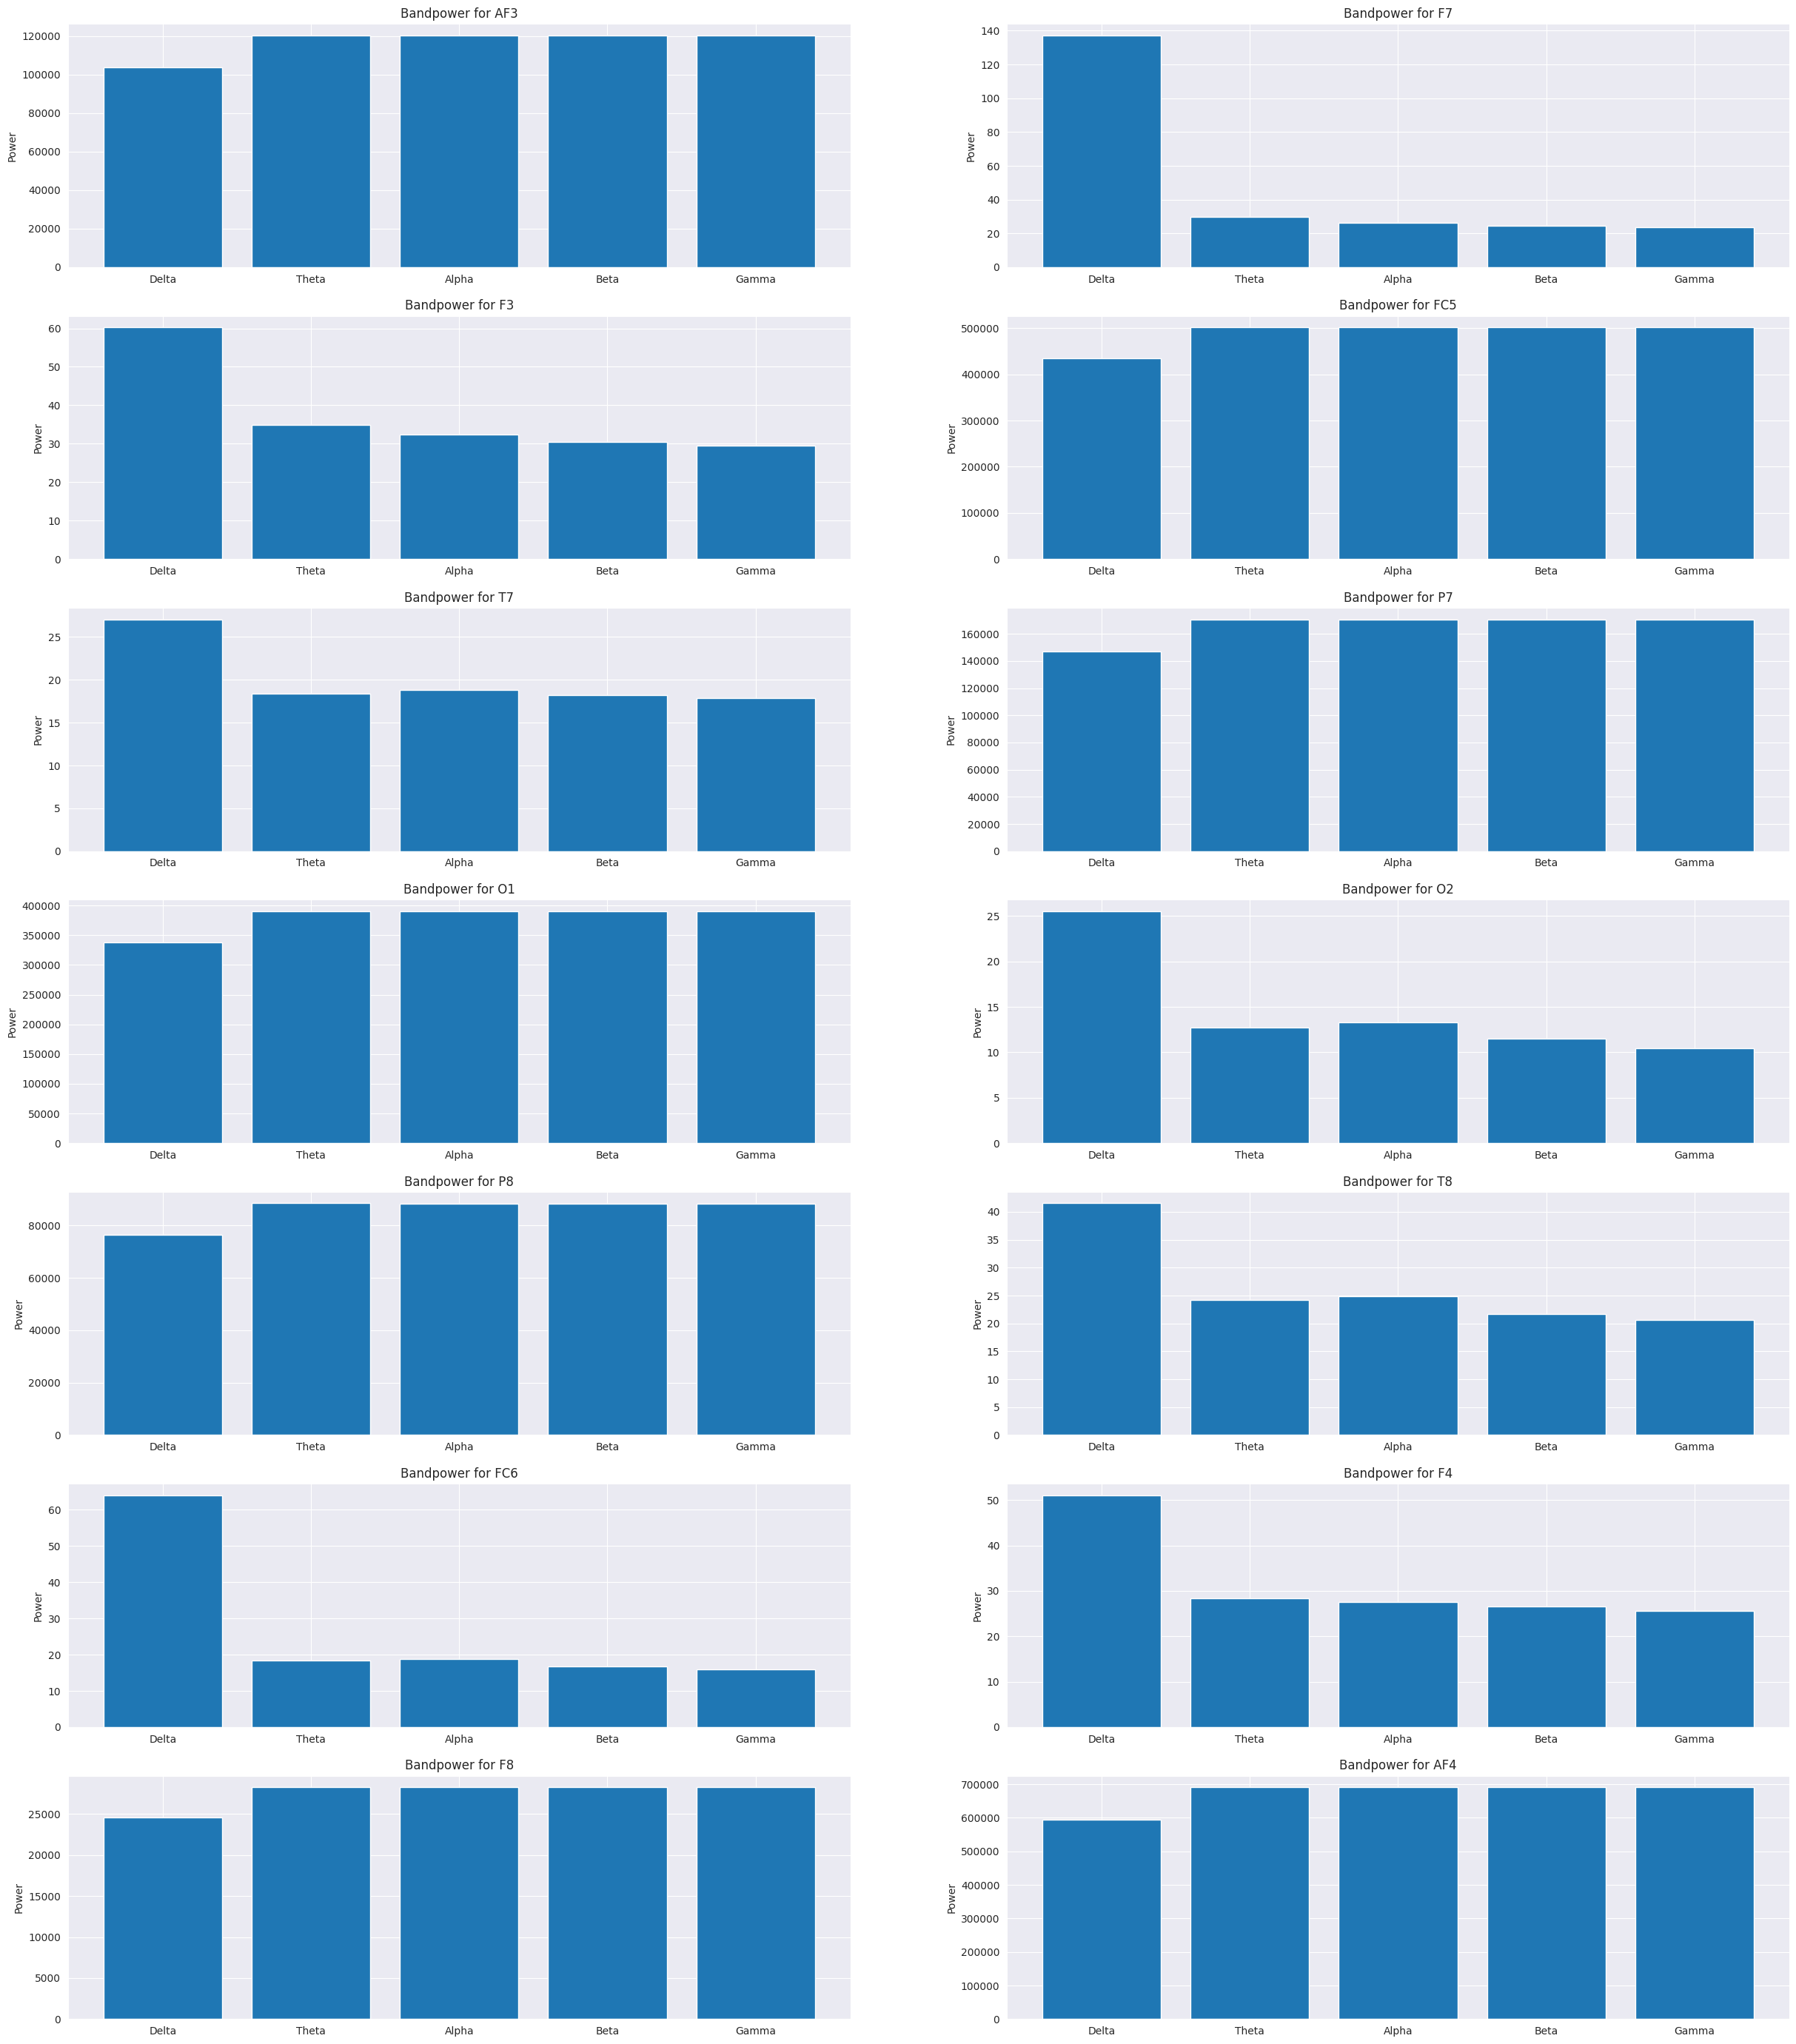

In [67]:
from scipy.signal import welch

columns = df.columns[:-1]

fig, axs = plt.subplots(len(columns)//2, 2, figsize=(30, 35))

for column in columns:
    f, Pxx = welch(df[column], fs=fs, window='hamming')
    bandpower = np.zeros(5)
    for i, (low, high) in enumerate([(0, 4), (4, 8), (8, 12), (12, 30), (30, 60)]):
        bandpower[i] = np.mean(Pxx[(f >= low) & (f < high)])
    ax = axs[columns.get_loc(column) // per_col, columns.get_loc(column) % per_col]
    ax.bar(np.arange(5), bandpower)
    ax.set_xticks(np.arange(5))
    ax.set_xticklabels(['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma'])
    ax.set_ylabel('Power')
    ax.set_title(f'Bandpower for {column}')

### Plot bandpower of each signal

We will calculate the bandpower of each signal and plot it. We will plot the relative bandpower of each signal and per target class.

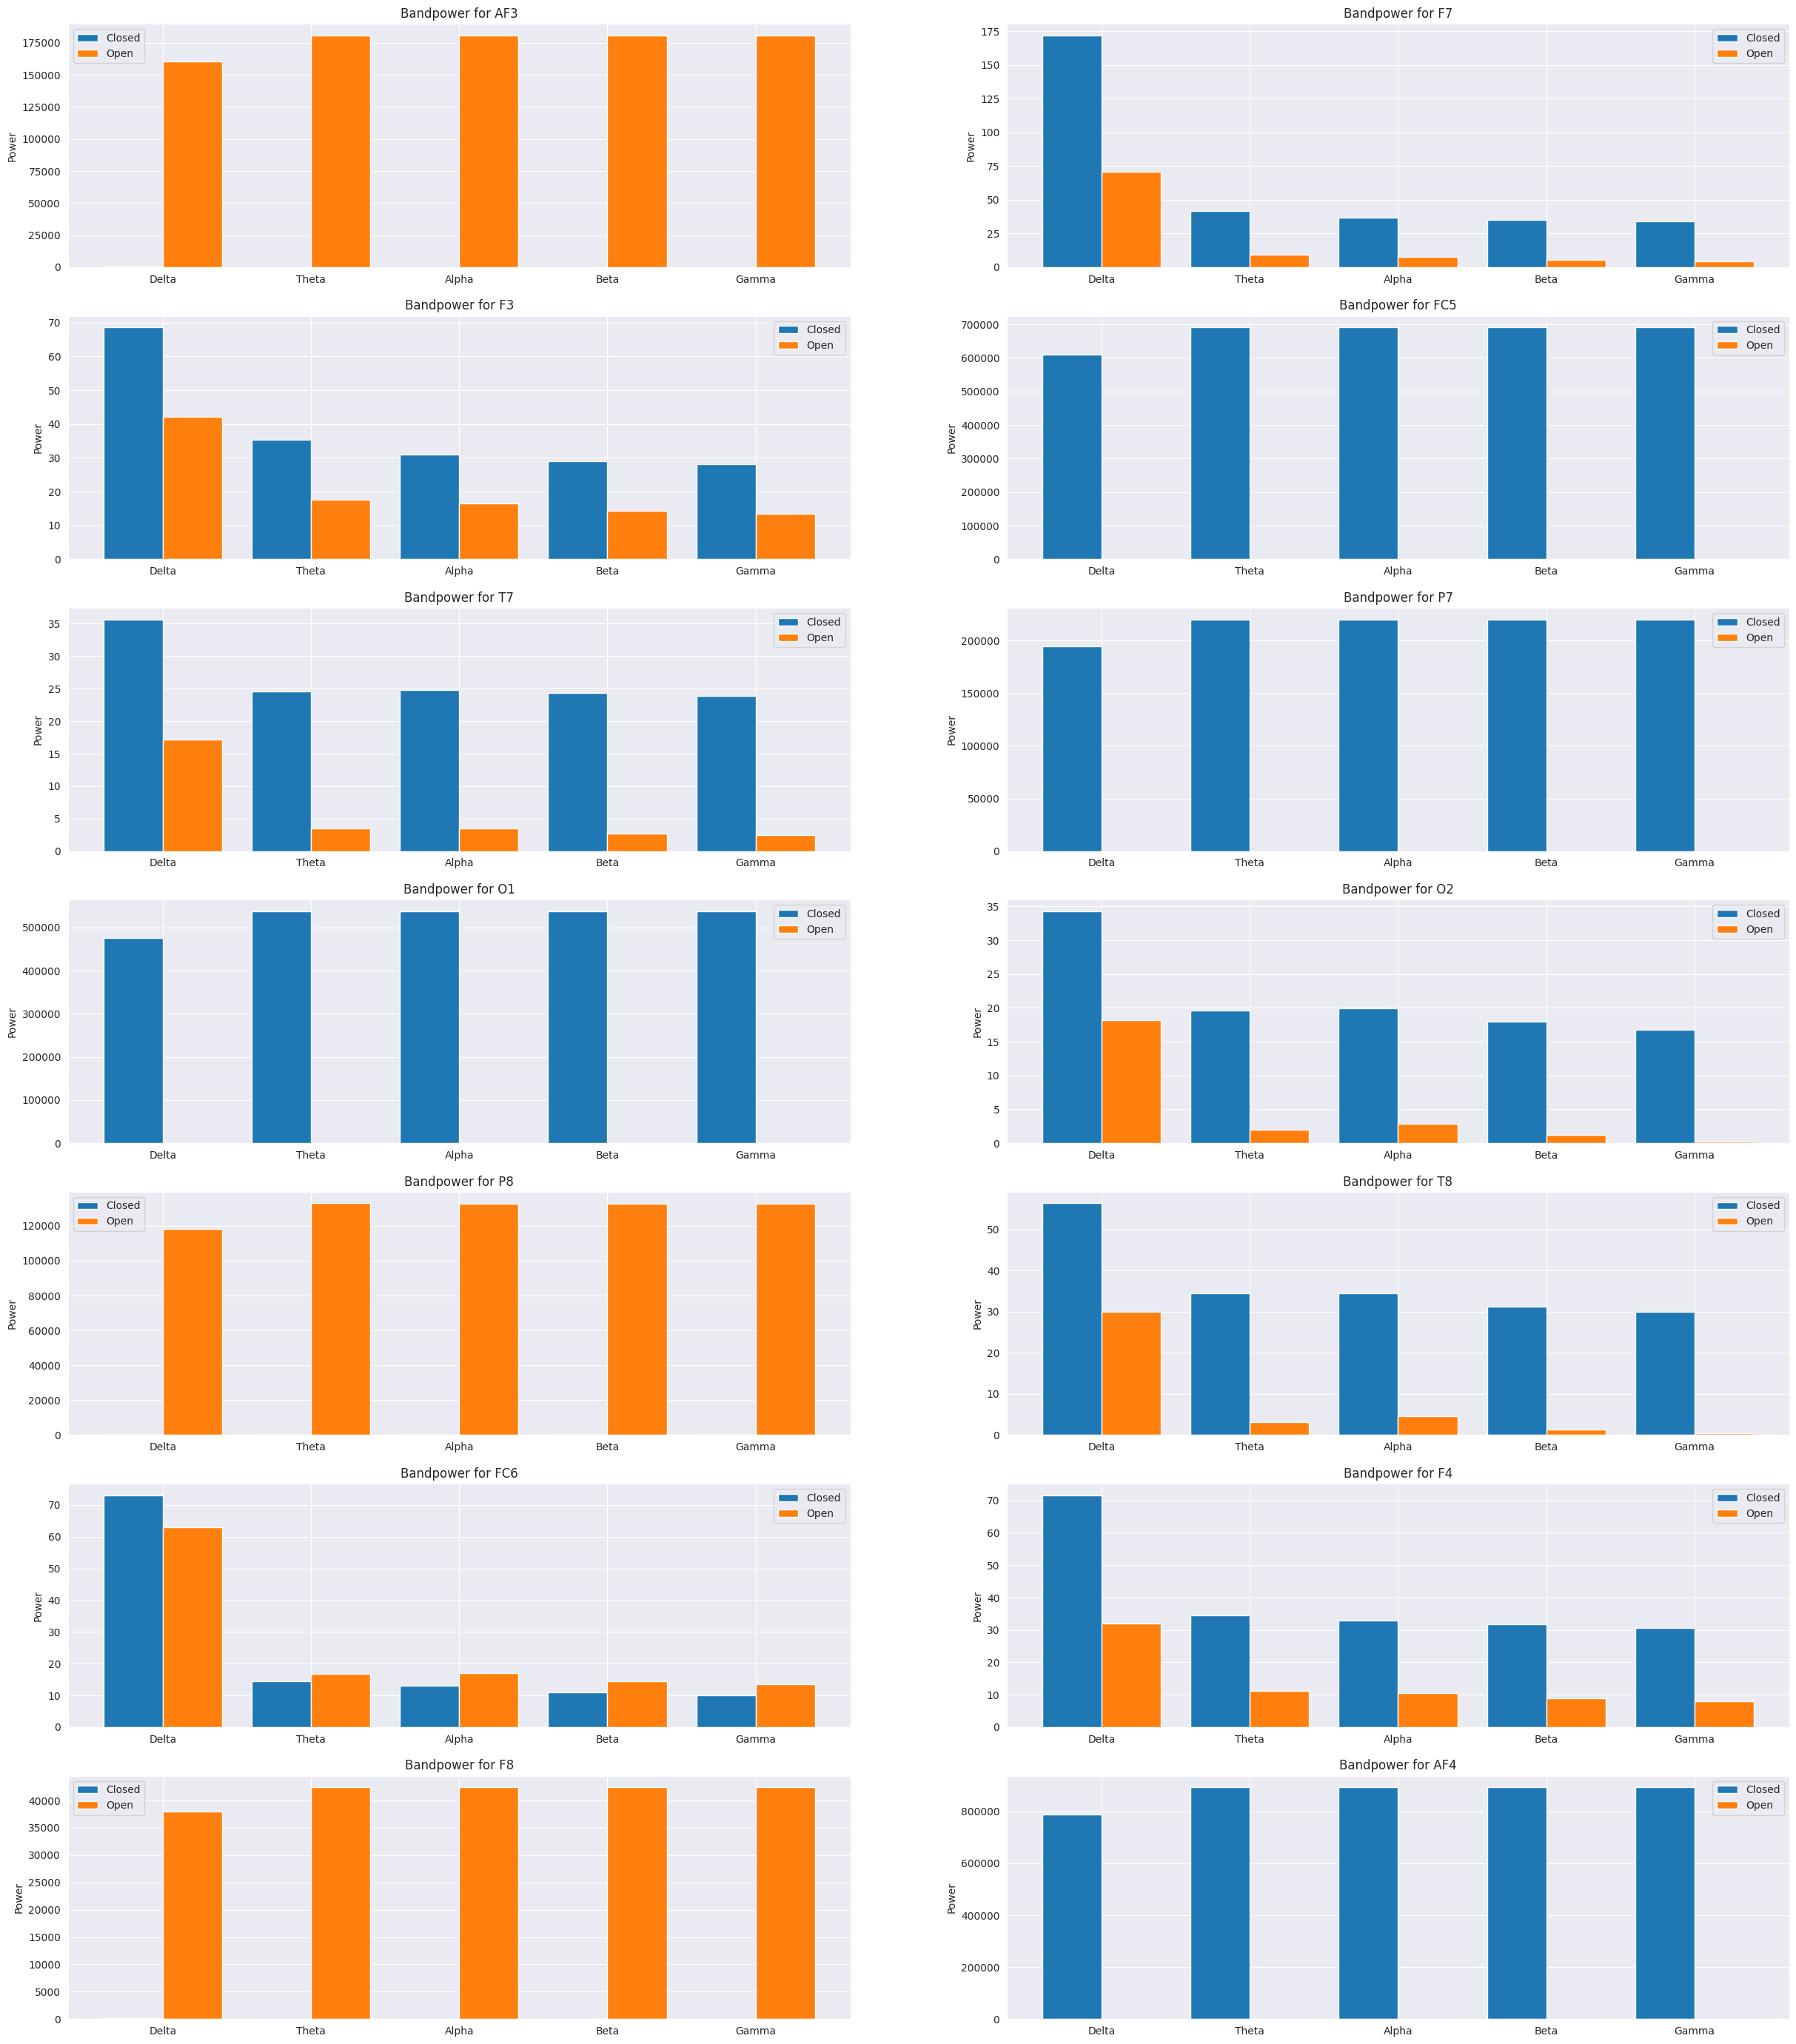

In [72]:
from scipy.signal import welch

columns = df.columns[:-1]

fig, axs = plt.subplots(len(columns)//2, 2, figsize=(30, 35))

for column in columns:
    bandpower = np.zeros((5, 2))
    for t in range(2):
        f, Pxx = welch(df[column][df['target'] == t], fs=fs, window='hamming')
        for i, (low, high) in enumerate([(0, 4), (4, 8), (8, 12), (12, 30), (30, 60)]):
            bandpower[i, t] = np.mean(Pxx[(f >= low) & (f < high)])
    # for i, (low, high) in enumerate([(0, 4), (4, 8), (8, 12), (12, 30), (30, 60)]):
    #     bandpower[i, 0] = np.mean(Pxx[(f >= low) & (f < high) & (df['target'] == 0)])
    #     bandpower[i, 1] = np.mean(Pxx[(f >= low) & (f < high) & (df['target'] == 1)])
    ax = axs[columns.get_loc(column) // per_col, columns.get_loc(column) % per_col]
    ax.bar(np.arange(5)-0.2, bandpower[:, 0], width=0.4, label='Closed')
    ax.bar(np.arange(5)+0.2, bandpower[:, 1], width=0.4, label='Open')
    ax.set_xticks(np.arange(5))
    ax.set_xticklabels(['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma'])
    ax.set_ylabel('Power')
    ax.set_title(f'Bandpower for {column}')
    ax.legend()

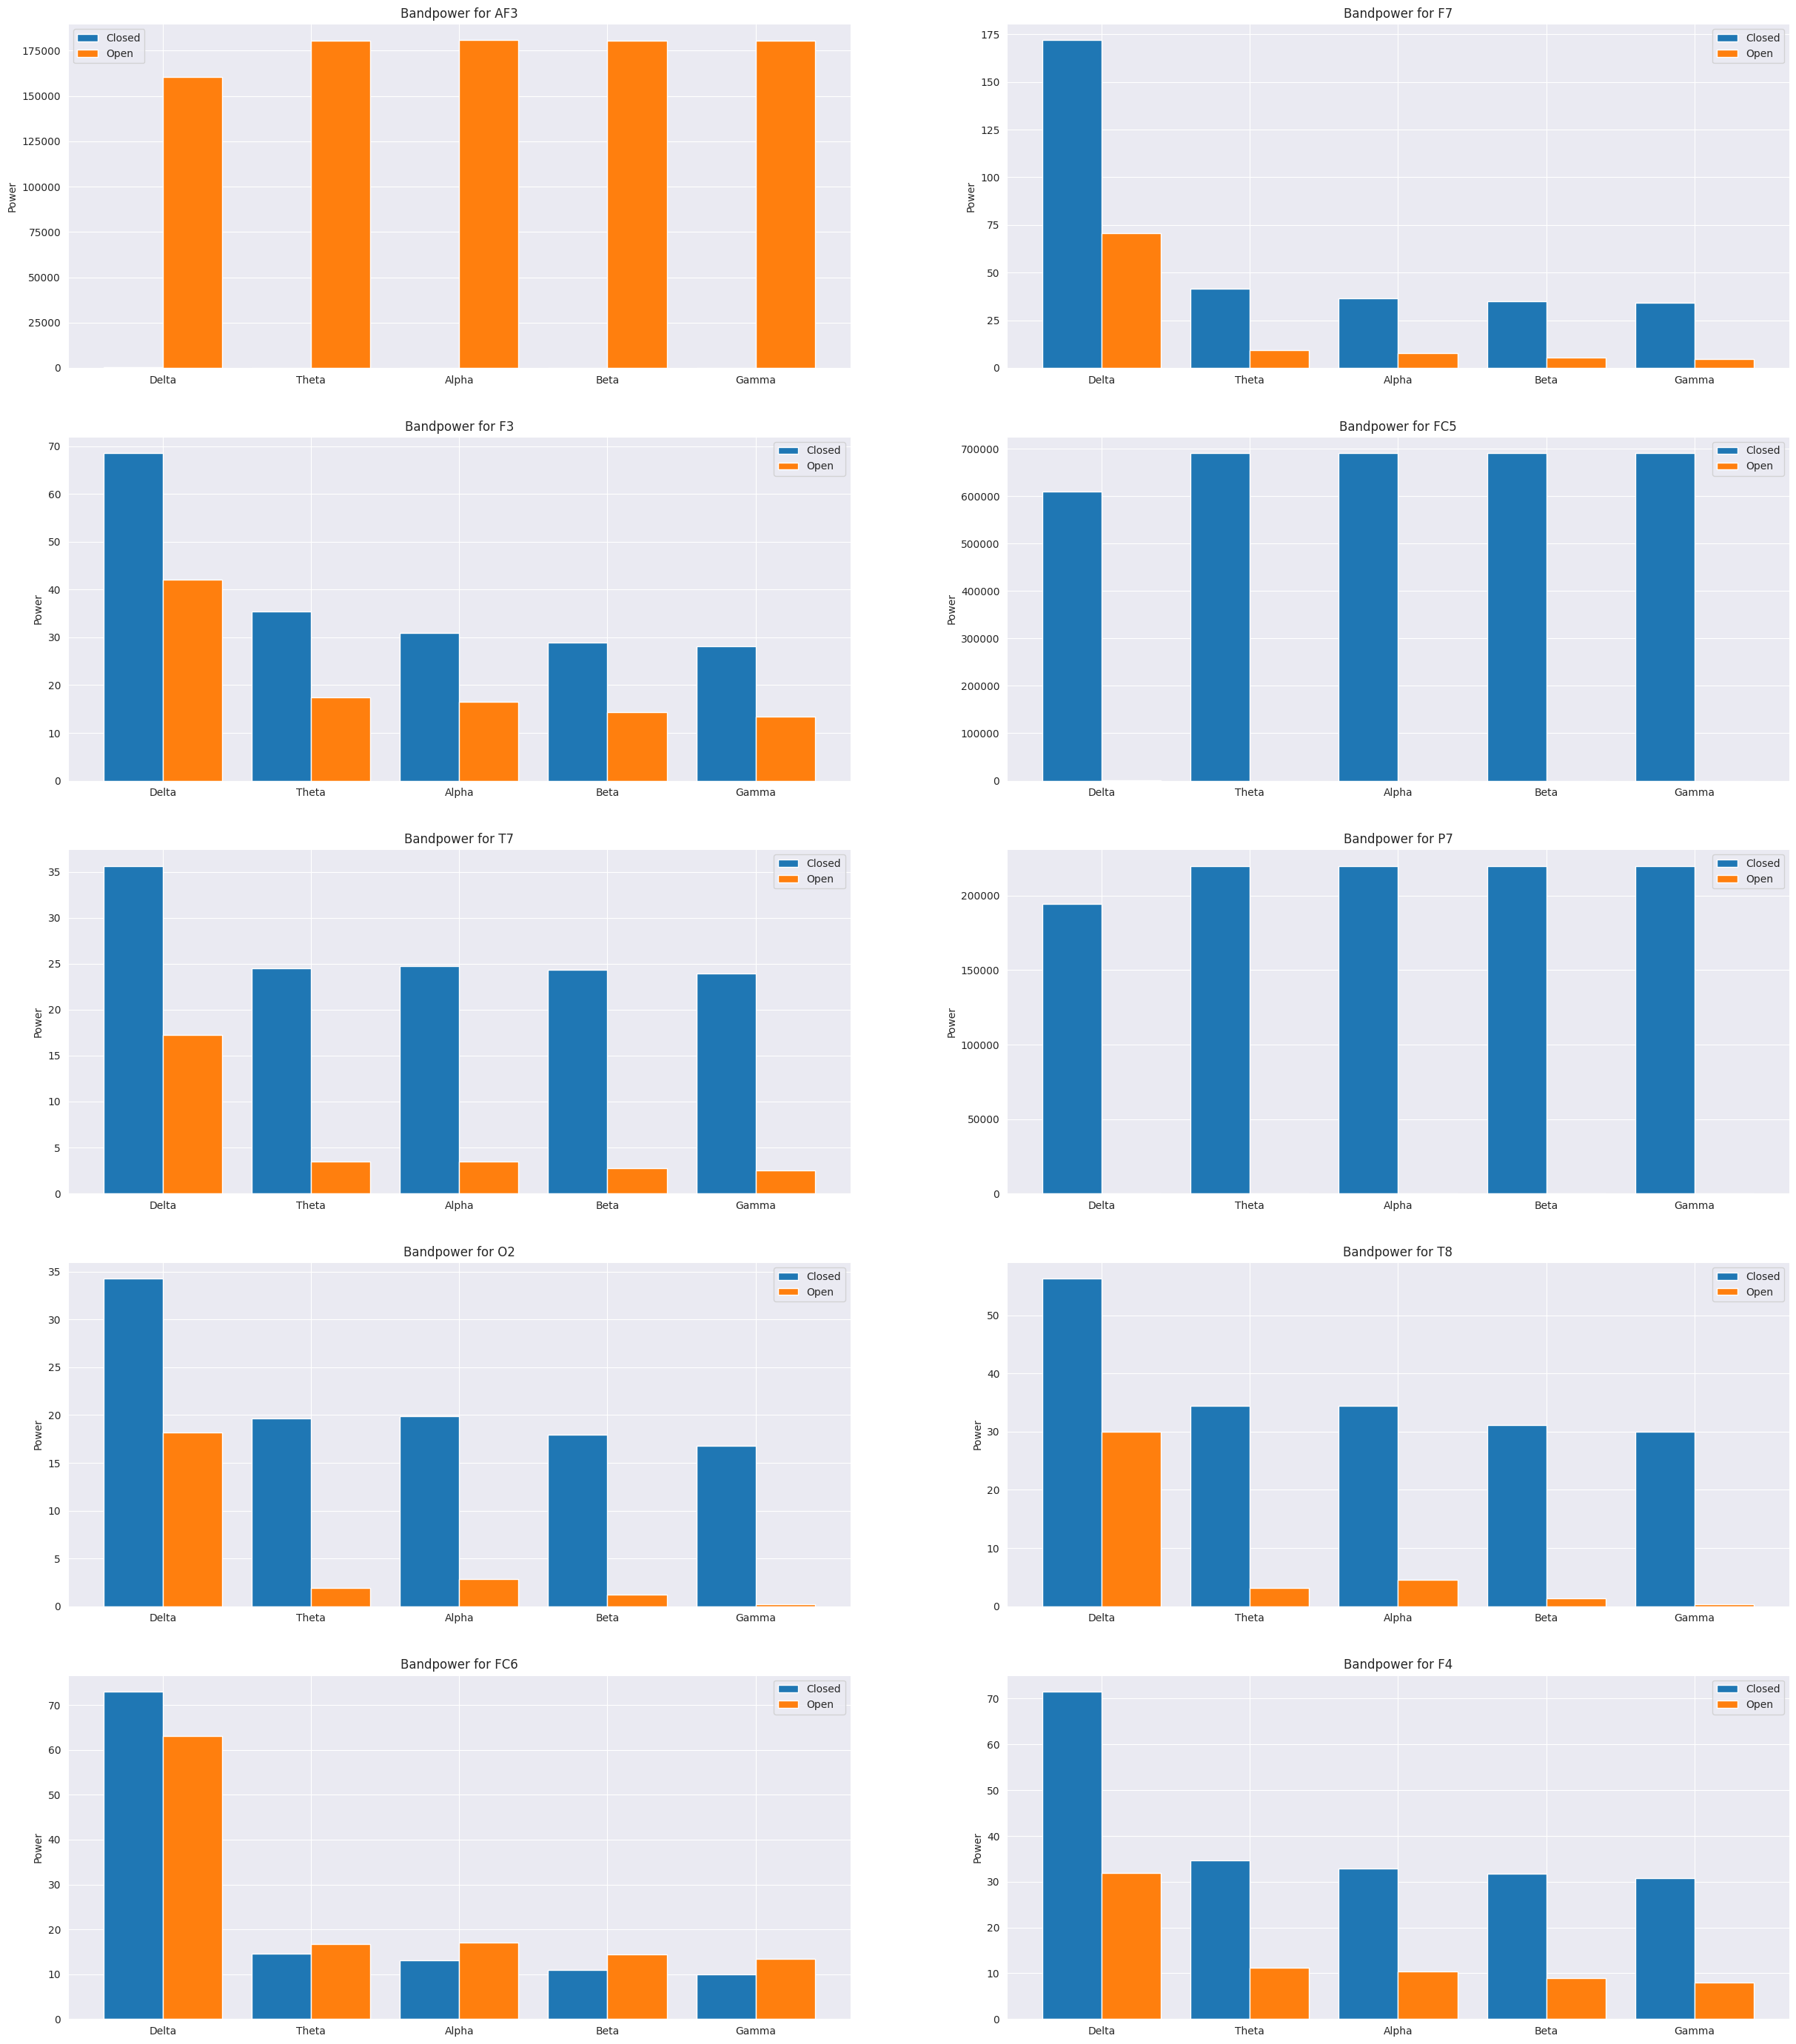

In [74]:
from scipy.signal import welch

columns = df.columns[df.columns.isin(selected_signals)]

fig, axs = plt.subplots(len(columns)//2, 2, figsize=(30, 35))

for column in columns:
    bandpower = np.zeros((5, 2))
    for t in range(2):
        f, Pxx = welch(df[column][df['target'] == t], fs=fs, window='hamming')
        for i, (low, high) in enumerate([(0, 4), (4, 8), (8, 12), (12, 30), (30, 60)]):
            bandpower[i, t] = np.mean(Pxx[(f >= low) & (f < high)])
    ax = axs[columns.get_loc(column) // per_col, columns.get_loc(column) % per_col]
    ax.bar(np.arange(5)-0.2, bandpower[:, 0], width=0.4, label='Closed')
    ax.bar(np.arange(5)+0.2, bandpower[:, 1], width=0.4, label='Open')
    ax.set_xticks(np.arange(5))
    ax.set_xticklabels(['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma'])
    ax.set_ylabel('Power')
    ax.set_title(f'Bandpower for {column}')
    ax.legend()

### Plot signal per target class

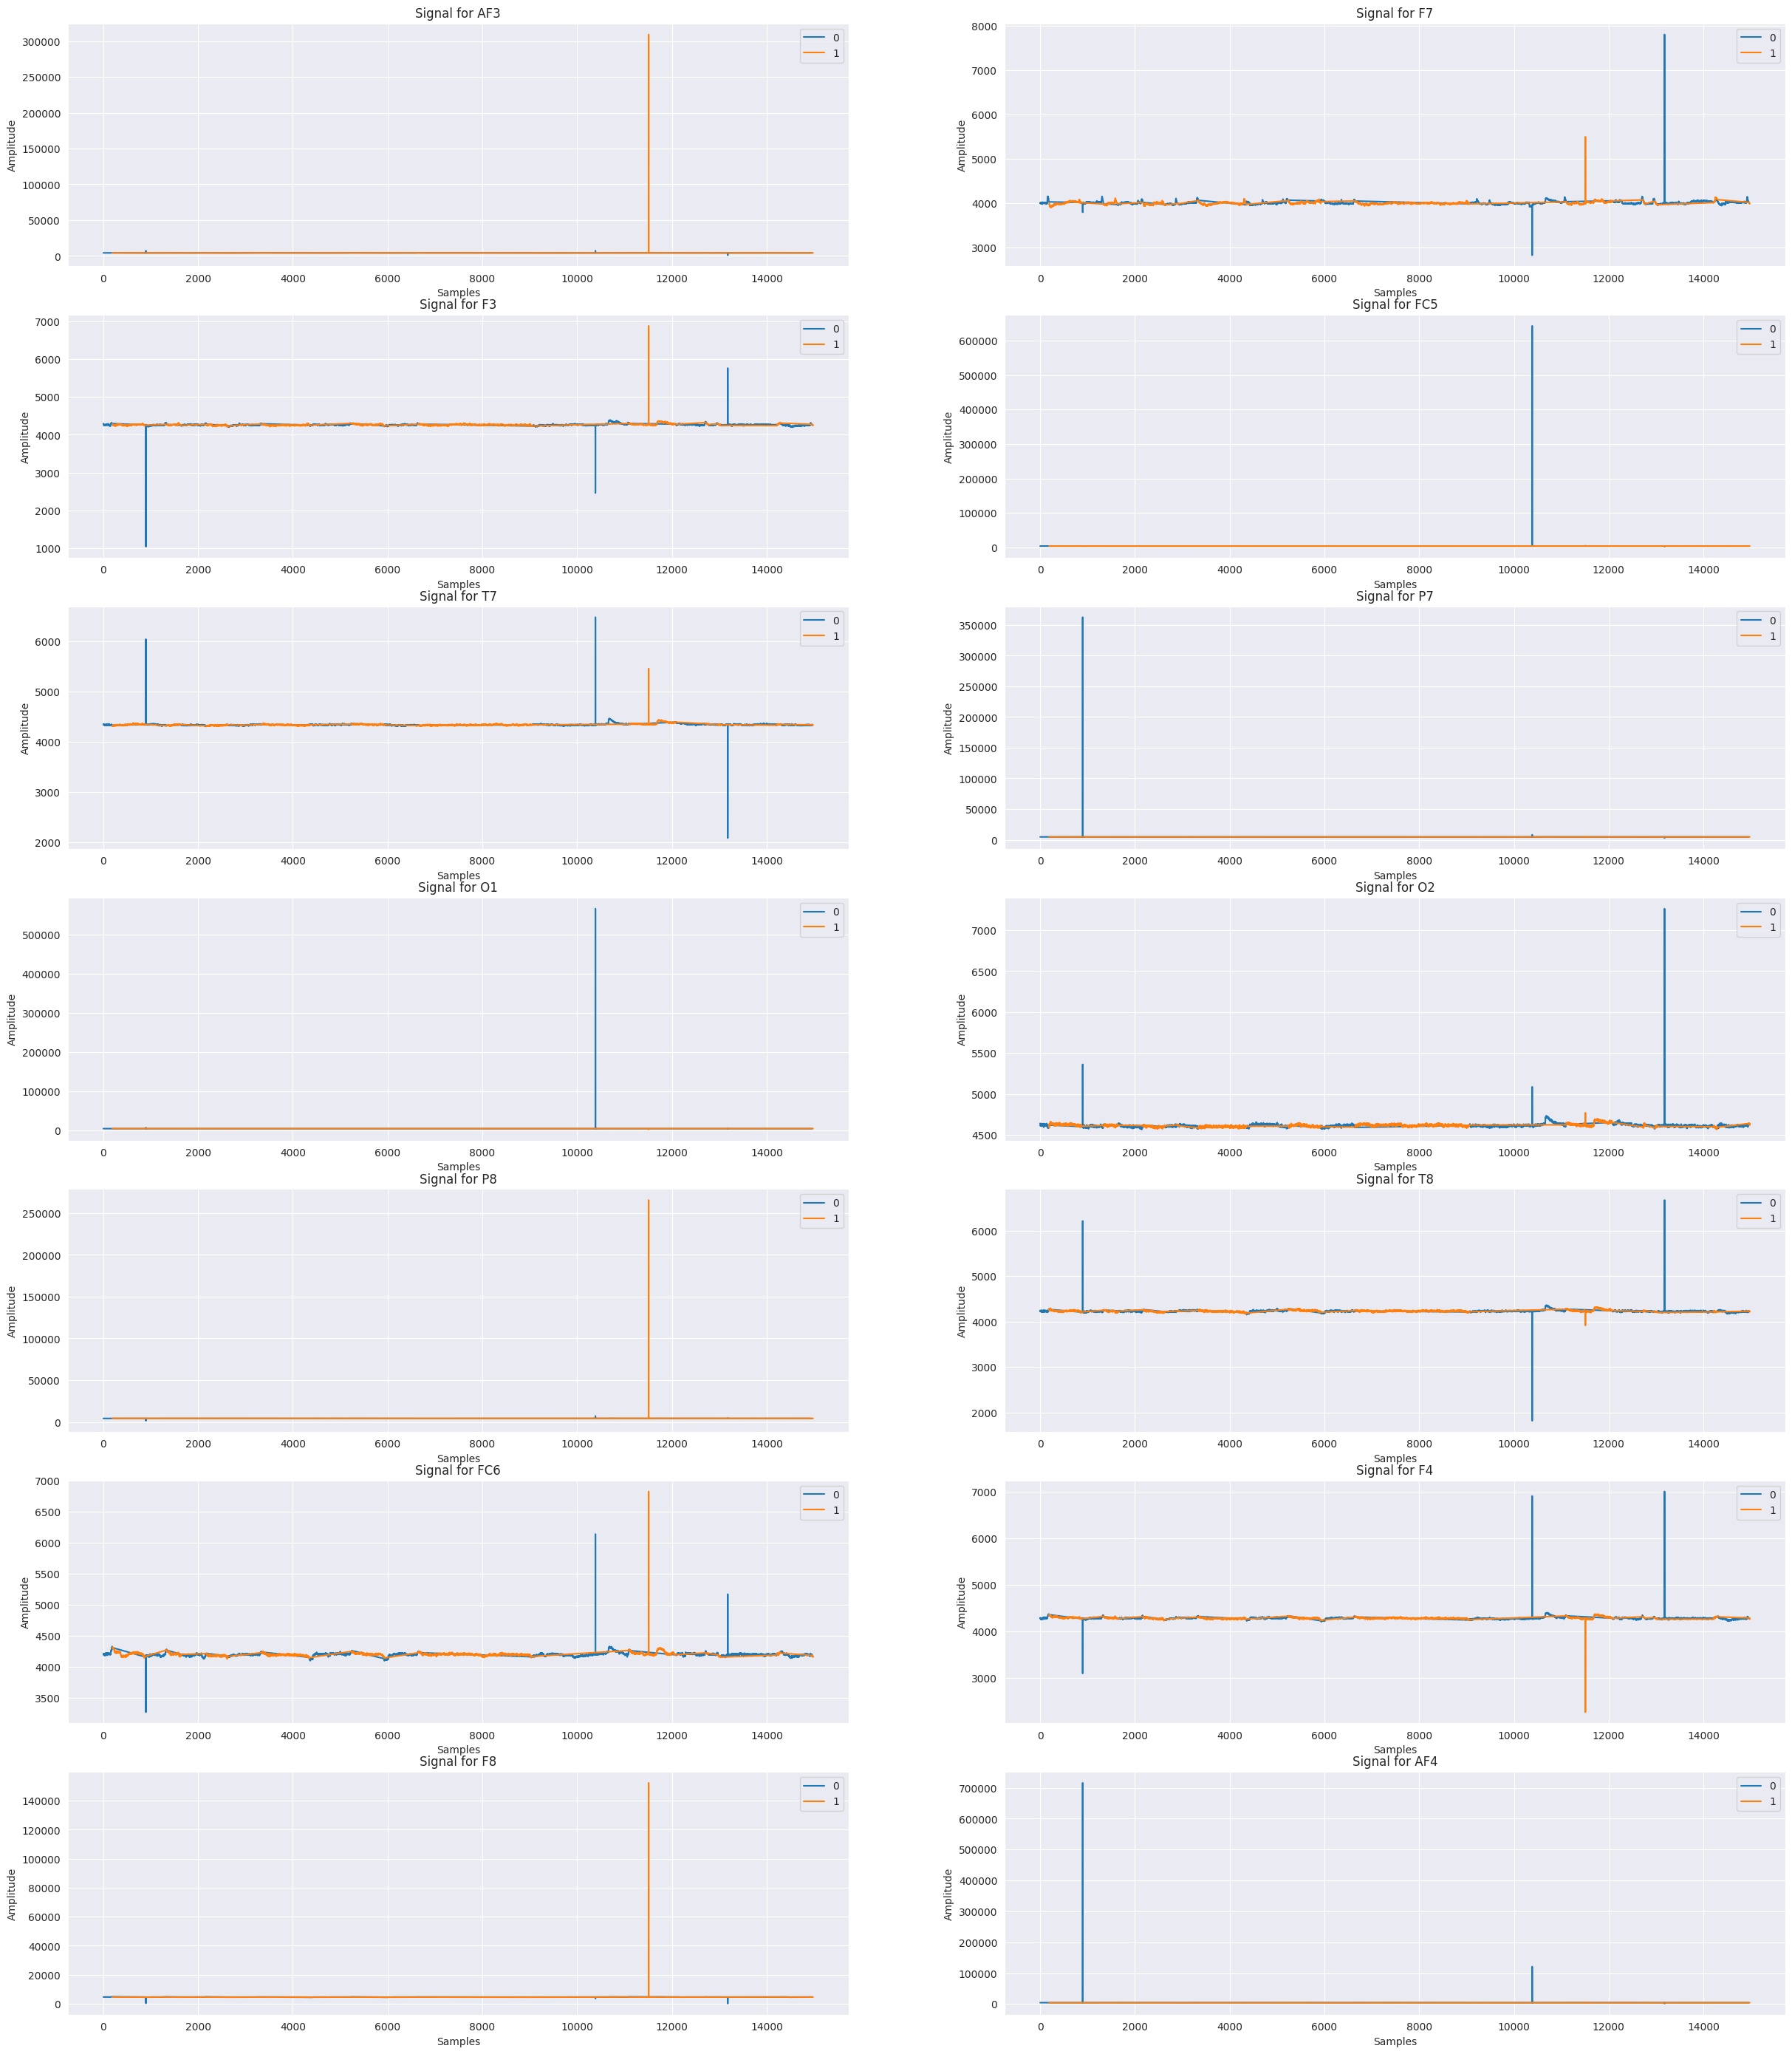

In [75]:
columns = df.columns[:-1]

fig, axs = plt.subplots(len(columns)//2, 2, figsize=(30, 35))

for column in columns:
    ax = axs[columns.get_loc(column) // per_col, columns.get_loc(column) % per_col]
    for t in range(2):
        ax.plot(df[column][df['target'] == t], label=f'{t}')    
    ax.legend()
    ax.set_xlabel('Samples')
    ax.set_ylabel('Amplitude')
    ax.set_title(f'Signal for {column}')

Text(0, 0.5, 'Target')

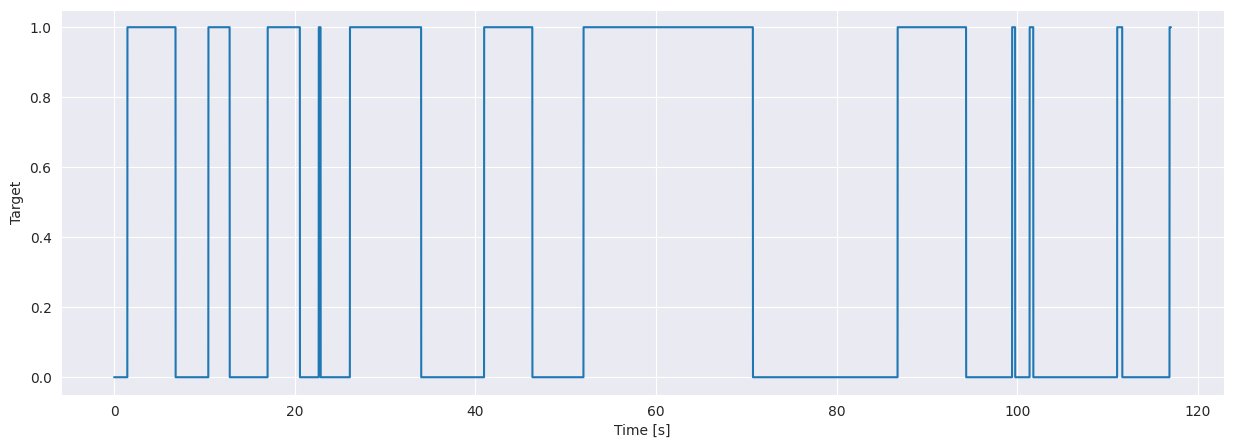

In [77]:
t = [i/fs for i in range(df.shape[0])]
plt.figure(figsize=(15,5))
plt.plot(t, df["target"])
plt.xlabel("Time [s]")
plt.ylabel("Target")

In [79]:
total_s = 117
total_samples = df.shape[0]
sf = int(total_samples/total_s)
print("The sampling frequency is", sf, "Hz")

The sampling frequency is 128 Hz


In [84]:
# Get segment of each target class
target_col = df.columns[-1]
last_target = df.loc[0, target_col]
segment = []
target_class = df[target_col].unique()
target_segments = {t: [] for t in target_class}
# Loop over each row of df 
for i in range(df.shape[0]):
    if df.loc[i, target_col] != last_target:
        target_segments[last_target].append(segment)
        last_target = df.loc[i, target_col]
        segment = [df.index[i]]
    else:
        segment.append(df.index[i])

# target_segments

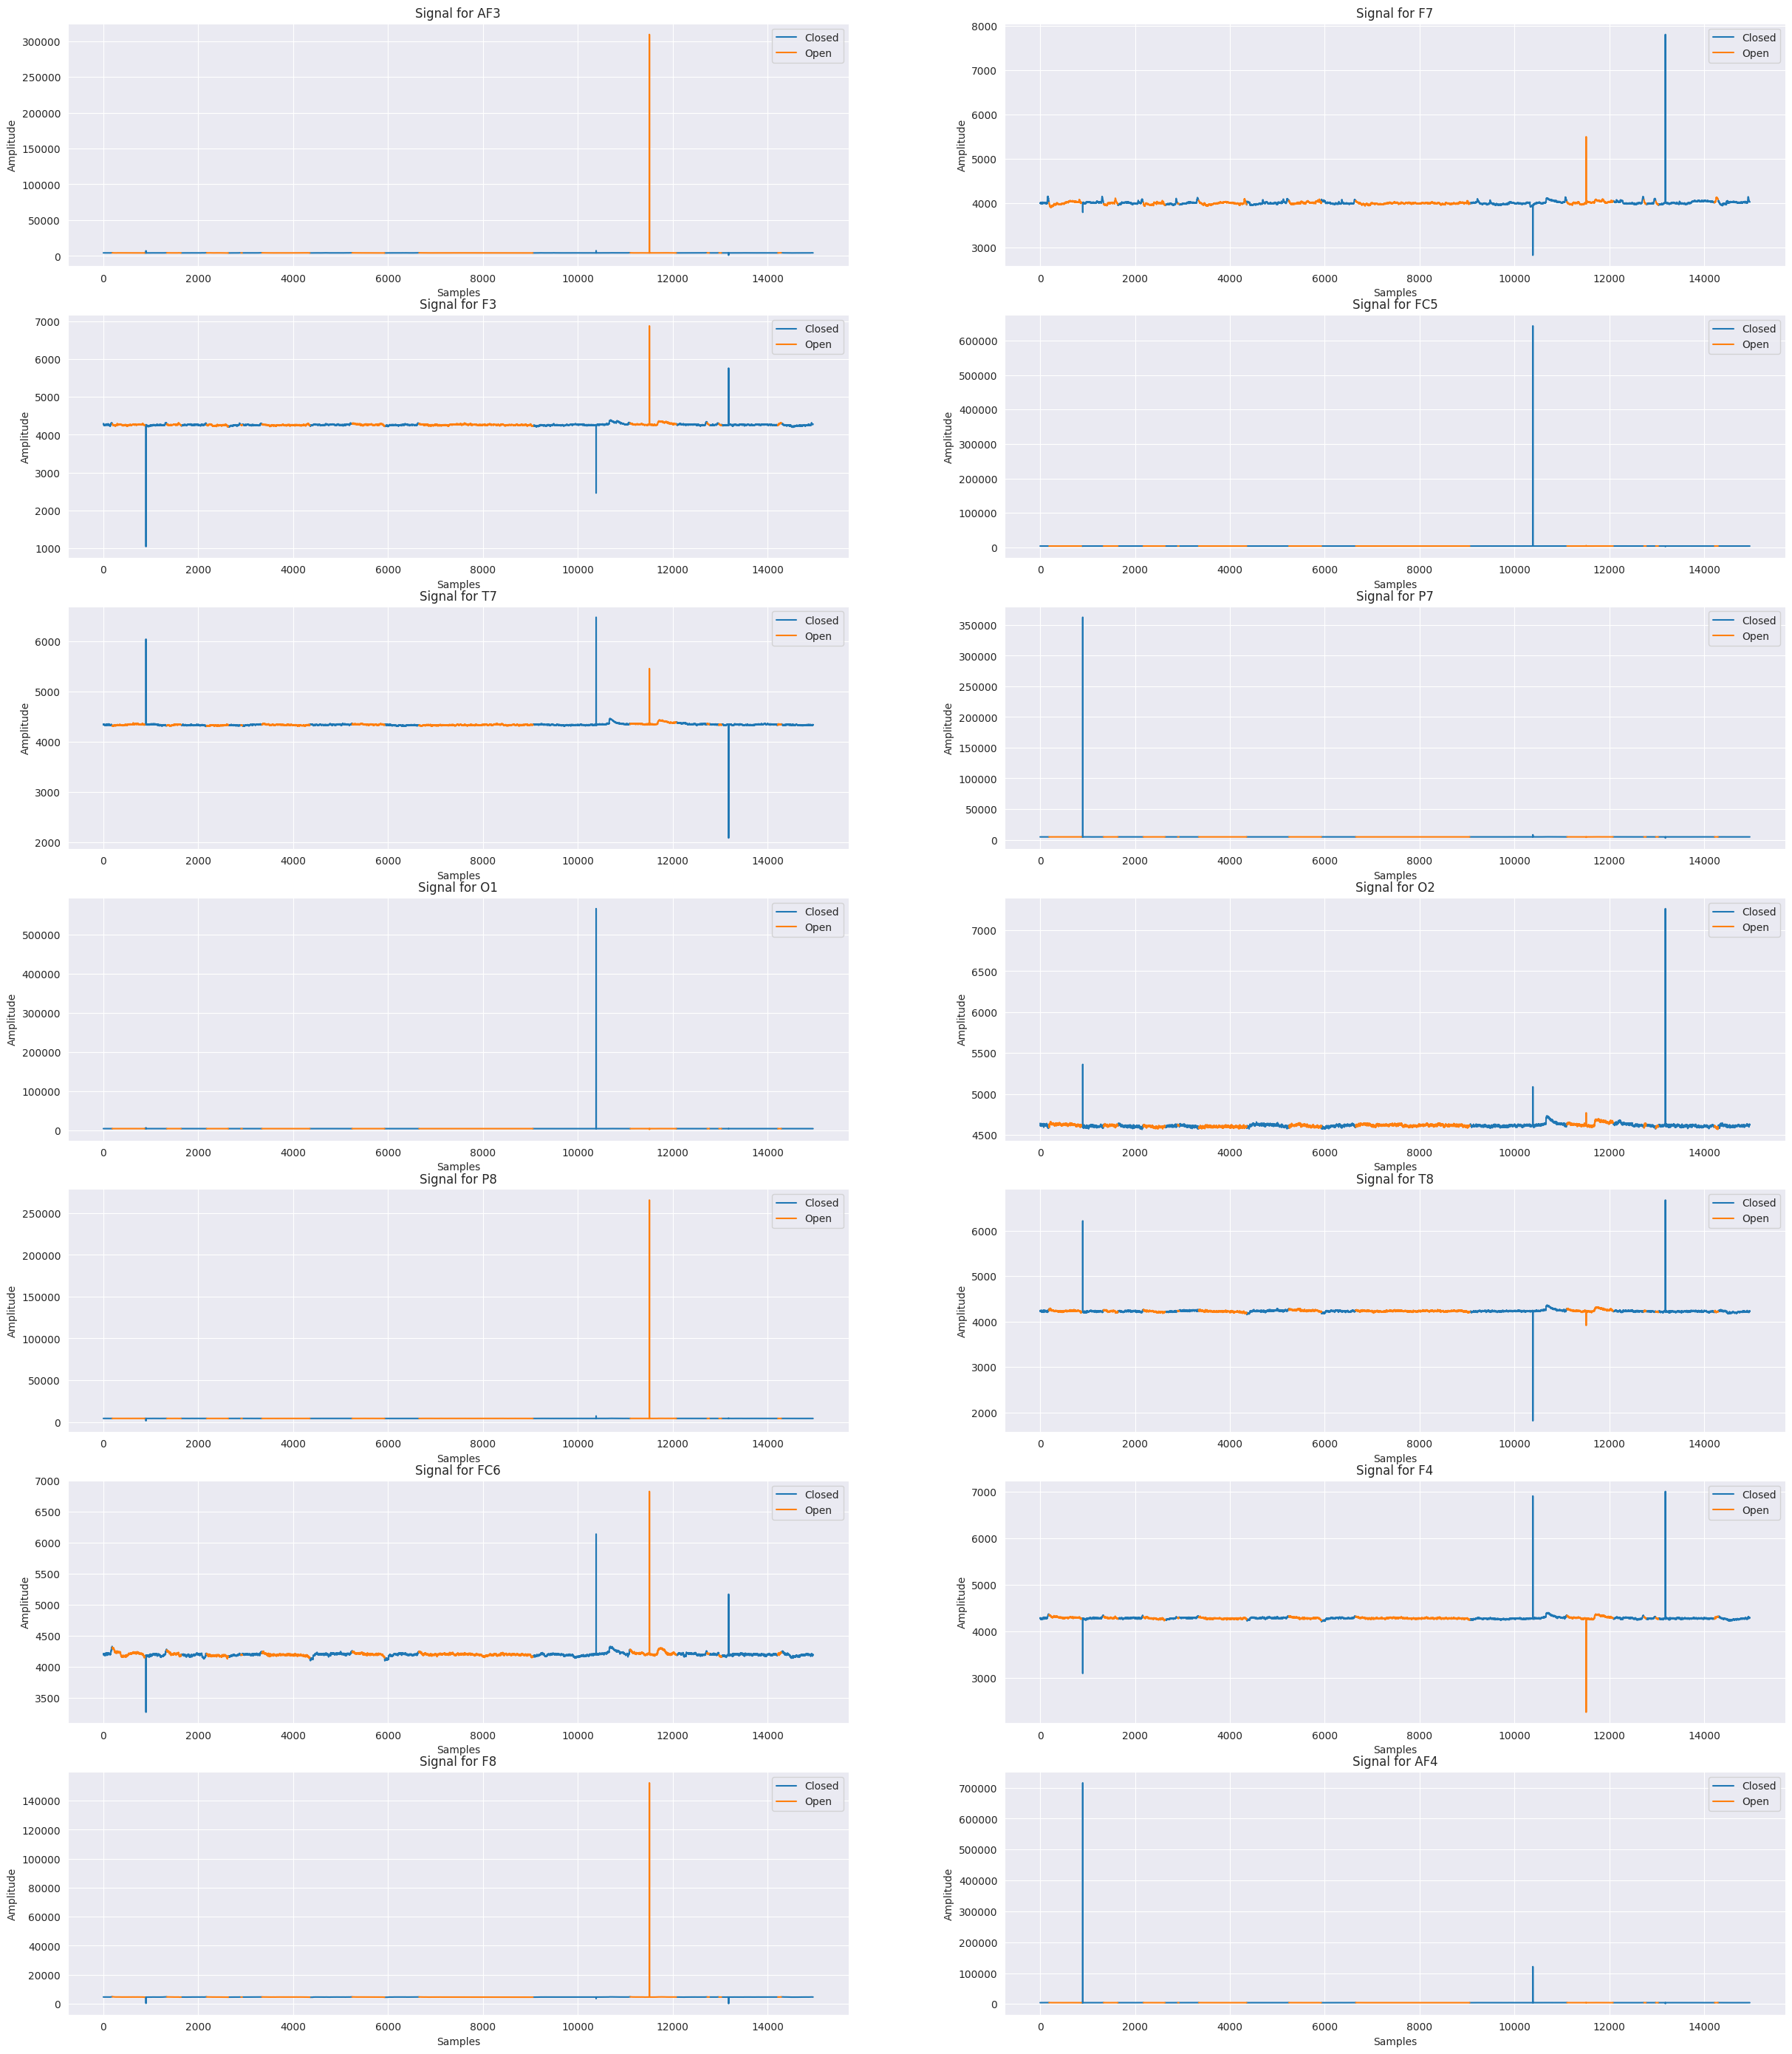

In [87]:
columns = df.columns[:-1]
id2label = {0: "Closed", 1: "Open"}

fig, axs = plt.subplots(len(columns)//2, 2, figsize=(30, 35))

for column in columns:
    ax = axs[columns.get_loc(column) // per_col, columns.get_loc(column) % per_col]
    for t in range(2):
        for i, s in enumerate(target_segments[t]):
            if i == 0:
                line = ax.plot(df[column].iloc[s], label=f'{id2label[t]}')
            else:
                ax.plot(df[column].iloc[s], color=line[0].get_color())
    ax.legend()
    ax.set_xlabel('Samples')
    ax.set_ylabel('Amplitude')
    ax.set_title(f'Signal for {column}')

### MNE and EEG data

Creating RawArray with float64 data, n_channels=14, n_times=14980
    Range : 0 ... 14979 =      0.000 ...   117.023 secs
Ready.
Fitting ICA to data using 14 channels (please be patient, this may take a while)
Selecting by number: 14 components


/tmp/ipykernel_2044901/787858215.py:23: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw)


Fitting ICA took 0.8s.


/tmp/ipykernel_2044901/787858215.py:23: RuntimeWarning: Using n_components=14 (resulting in n_components_=14) may lead to an unstable mixing matrix estimation because the ratio between the largest (7) and smallest (4.3e-06) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 12
  ica.fit(raw)


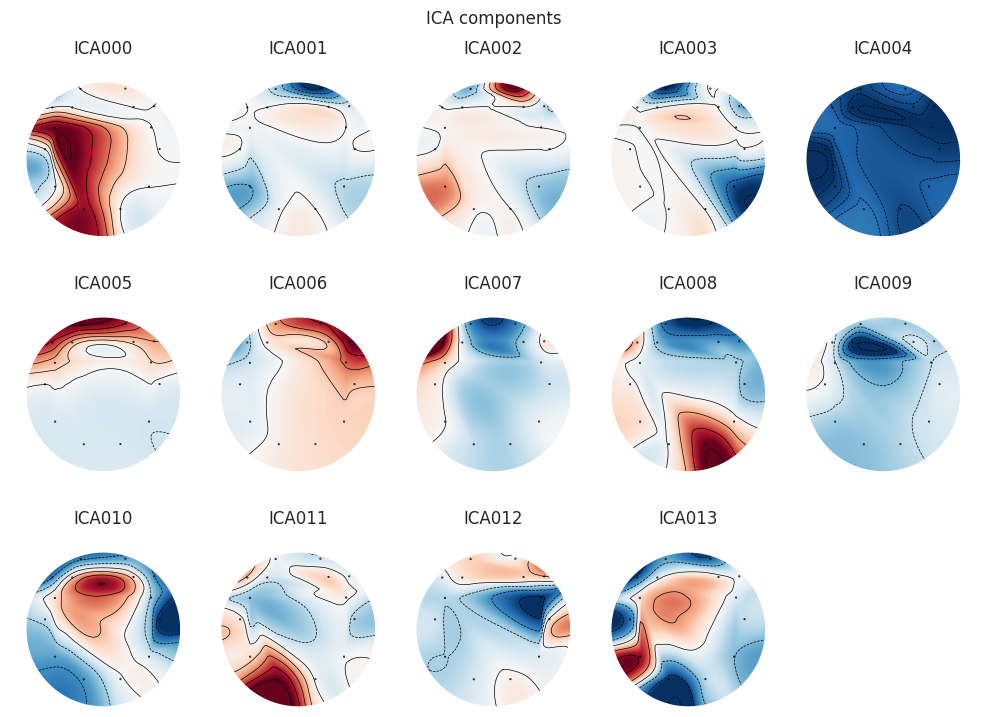

Creating RawArray with float64 data, n_channels=14, n_times=14980
    Range : 0 ... 14979 =      0.000 ...   117.023 secs
Ready.
Using matplotlib as 2D backend.


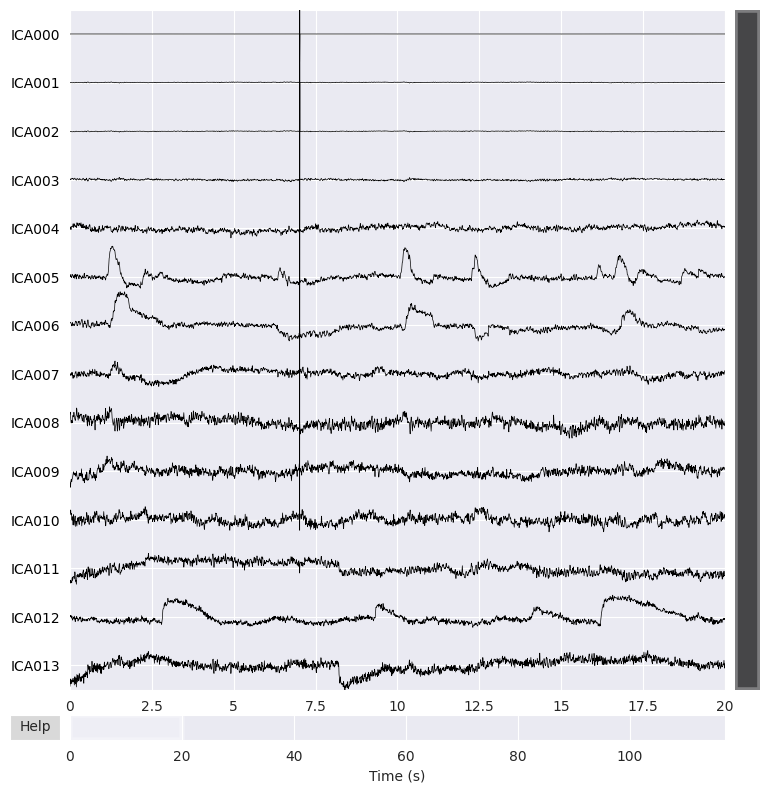

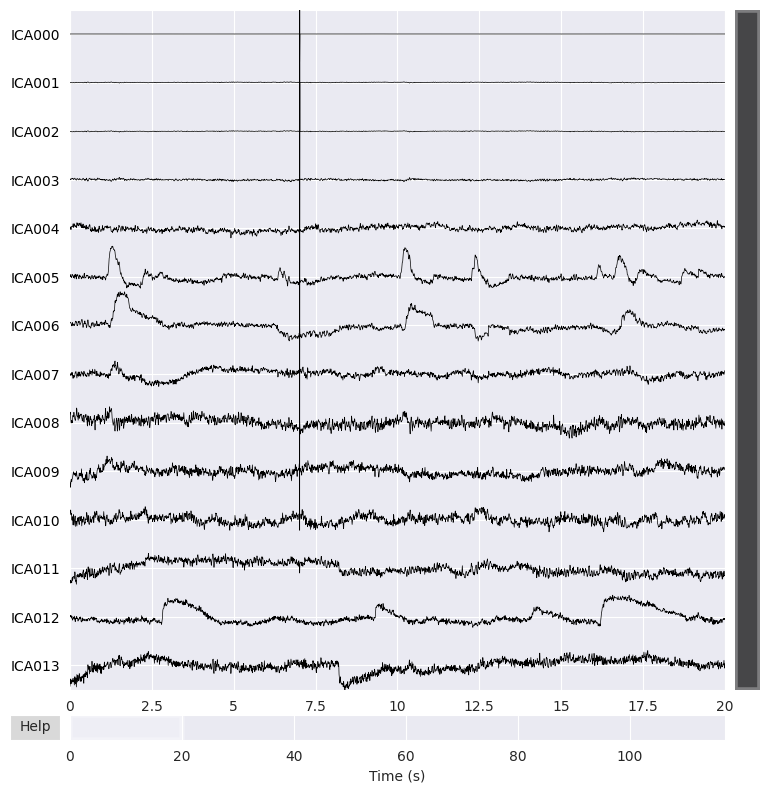

In [8]:
import mne
from mne.preprocessing import ICA

fs = 128   # Sampling frequency

# Extract EEG channels (excluding EyeDetection for now)
eeg_channels = df.columns[:-1].tolist()
eeg_data = df[eeg_channels].values.T  # Transpose for MNE (channels x time)

# Create info and raw object
info = mne.create_info(ch_names=eeg_channels, sfreq=fs, ch_types='eeg')
raw = mne.io.RawArray(eeg_data, info)

# Load the standard 10-20 montage
montage = mne.channels.make_standard_montage('standard_1020')

# Apply the montage to the raw object
raw.set_montage(montage)

# Initialize ICA, selecting the number of components (try starting with the number of channels)
n_components = len(eeg_channels)  # Initial choice, adjust based on inspection
ica = ICA(n_components=n_components, random_state=0, max_iter='auto')
ica.fit(raw)

# Plot components (spatial map)
ica.plot_components()

# Plot time series of sources to identify noisy patterns (like eye blinks or muscle artifacts)
ica.plot_sources(raw)

Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


/home/paquetlab/workspace/EEG_Interface/.venv/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


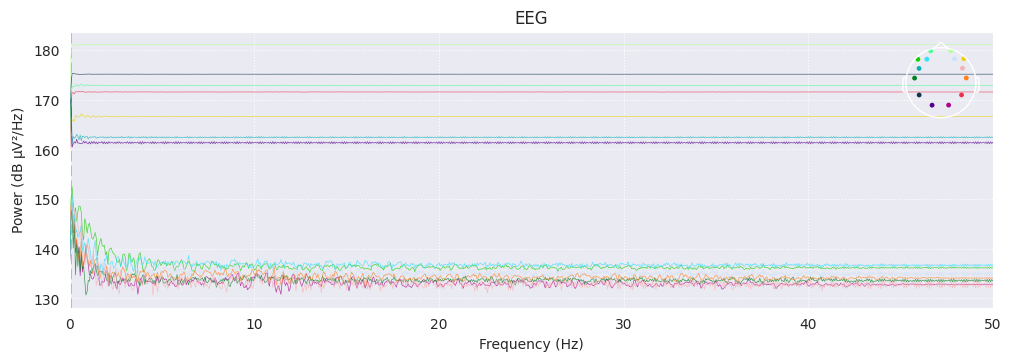

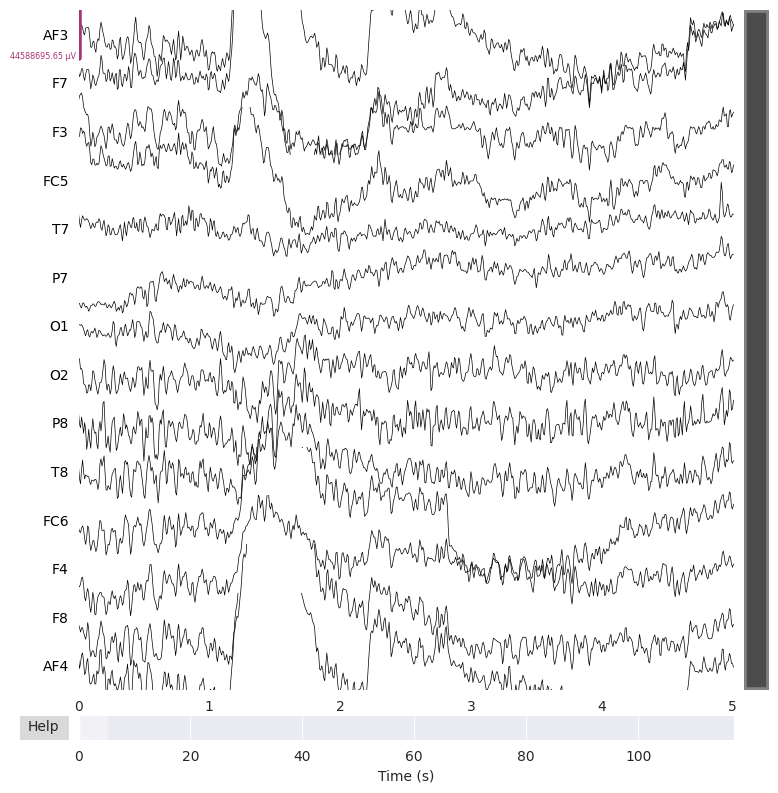

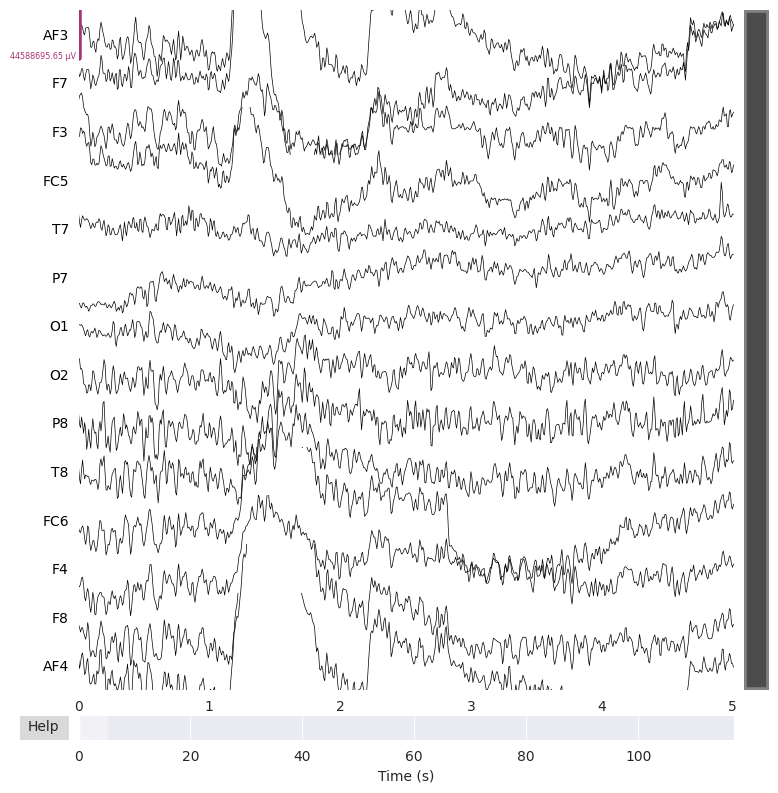

In [12]:
raw.compute_psd(fmax=50).plot(picks="data", exclude="bads", amplitude=False)
raw.plot(duration=5, n_channels=n_components, scalings='auto')

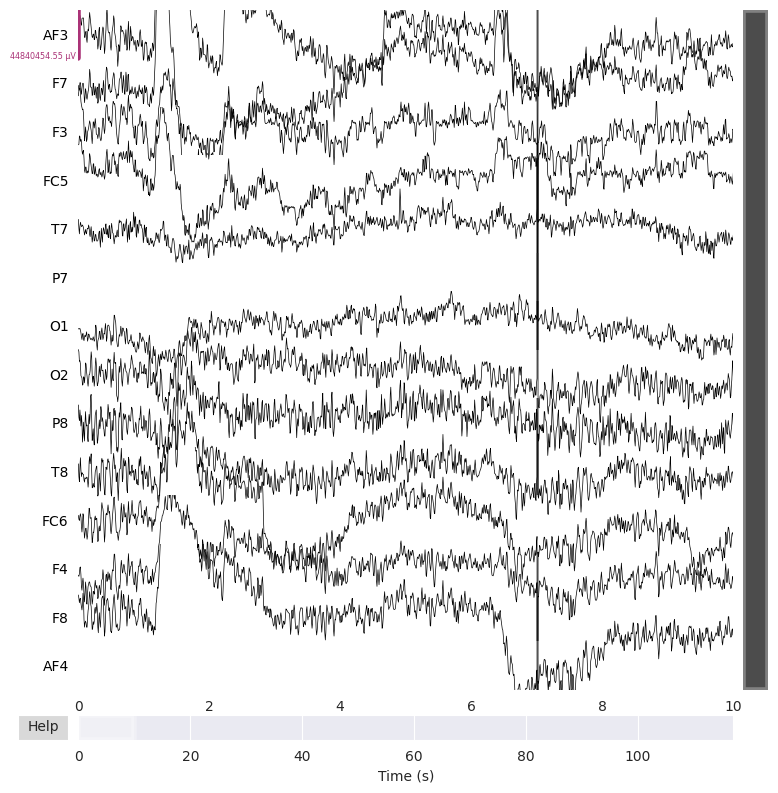

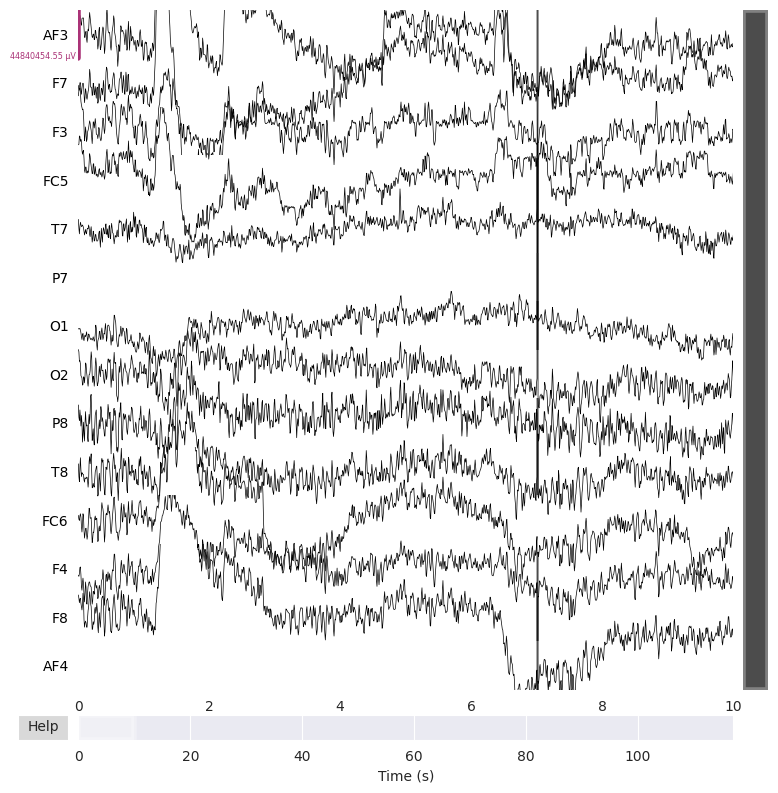

In [14]:
raw.plot(scalings='auto')

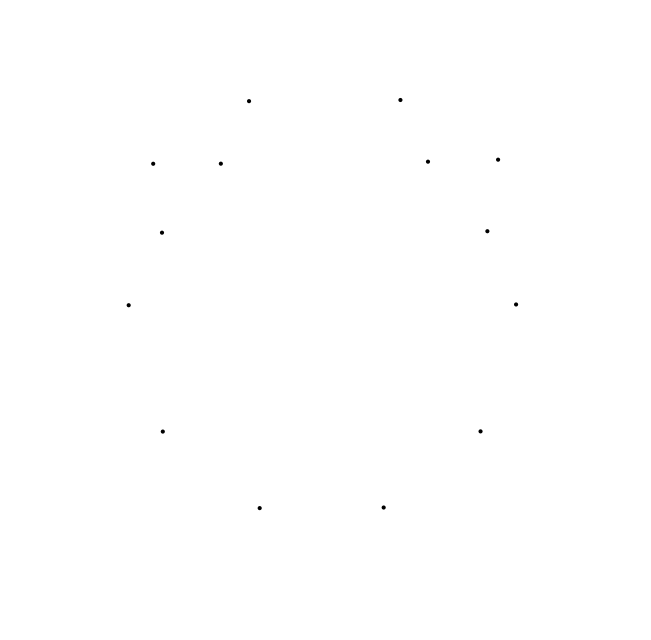

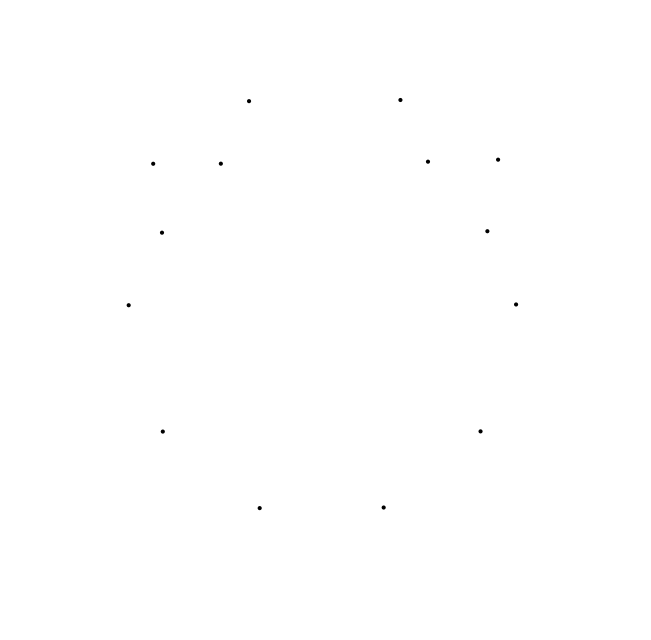

In [15]:
raw.plot_sensors(ch_type="eeg")